# Upoznavanje sa kreiranim skupom podataka

In [23]:
import argparse
import re
import statistics
from dataclasses import dataclass, field, asdict
from pathlib import Path
import pandas as pd
from collections import Counter
import langdetect
import matplotlib.pyplot as plt
import tqdm
from enum import Enum
import json
import os
from itertools import combinations
import numpy as np
from IPython.display import display

## Analiza tekstualnih dokumenata iz Project Gutenberg skupa podataka

Skripta koja se koristi za analizu tekstualnih dokumenata iz Project Gutenberg skupa podataka.

**Cilj**: Eksplorativna analiza podataka i upoznavanje sa knjigama kroz ceo skup.

**Pitanja na koje analiza odgovara**:

1. START/END marker provera - Koliko knjiga sadrži nekakvu vrstu markera koji označavaju početak/kraj knjige? Radiće se upotrebom regularnih izraza. Korisno kako bi se filtriranje uradilo uz izbegavanje metapodataka knjiga.

1. Proveriti koliko ukupno i koliko često knjige imaju [] i provera da li je taj tekst koristan ili ga je moguće odbaciti - zapisati kao multiset (tekst: broj pojavljivanja).

1. Pogledati koliki broj knjiga nema korisnu sadržinu nakon izdvajanja markera i odbacivanja teksta u [], što se procenjuje na 2 načina (dovoljno je 1 da važi): tekst je manji od 100 reči ili odbačeno je 50% teksta tokom ranijeg procesa. Za same knjige će biti navedeno koliko je reči bilo pre, a koliko posle svega. Takođe će postojati i jedno bool polje for_deleting - true vrednost označava da se knjiga neće unositi u baze podataka, odnosno false znači da će se unositi.

1. Provera postojanja poglavlja - Koliko knjiga uopšte ima poglavlja u svojoj sadržini? Korisno za potrebe structure aware chunking dela strategije.

1. Distribucija dužine poglavlja kao i broja samih poglavlja i celih knjiga koje nemaju poglavlja. Radi se paralelni prikaz dužina knjiga sa i bez poglavlja. Računaće se: min/max/mean/median, prikazaće se histogram i boxplot. Pored ovoga, za svaku knjigu će se navesti min/max/mean/median po poglavljima, ali isto tako i polje koje će nam biti značajno kasnije: has_chapters - korisno za samu pretragu jer se time naglašava da knjiga nema uopšte poglavlja i takođe se preskače pretraga po chapter_summary kolekciji.

1. Provera da li knjige imaju neki vid sadržaja dela na početku ili kraju obrađene knjige (10% knjige) - može biti korisno za potrebe structure aware chunking dela strategije.

1. Heuristika min/max/mean/median za svaku knjigu (broj reči po liniji, gustina interpunkcije po liniji) - Korisno kako bi se uradila gruba klasifikacija na prozu/poeziju.

1. Statistika samog pojavljivanja jezika u knjigama. Za potrebe ovoga koristiće se neka biblioteka kao što je langdetect. Pokazaće nam koliku važnost igra multilingualnost samih modela: LLM za sažetke i modela ugrađivanja.


**Rezultat**: Nakon toga je potrebno kreirati jedan novi fajl u kom će se navesti odgovori na ranija pitanja, što može biti korisno za kasnije procedure chunking-a, unosa, kreiranja sažetaka itd.   

In [38]:
# ---------------------------------------------------------------------------
# Regex-i
# ---------------------------------------------------------------------------

# Generički pattern za regex-e koji koristimo da bismo uhvatili što je moguće više knjiga, jer nam nisu svi rasporedi početaka poznati.
GENERIC_START_RE = re.compile(r"\*\*\*\s*START.{0,300}?\*\*\*", re.IGNORECASE | re.DOTALL)
GENERIC_END_RE = re.compile(r"\*\*\*\s*END.{0,300}?\*\*\*", re.IGNORECASE | re.DOTALL)

# Sadržaj (Table of contents) - tražimo reč "content" na svojoj liniji (case-insensitive). Služi za proveru da li je TOC u prvih 10% ili poslednjih 10% knjige.
TOC_HEADING_RE = re.compile(r"^\s*(contents|table of contents|content|table of content)\s*$", re.IGNORECASE | re.MULTILINE)

# Chapter marker - (npr. "Chapter 1", "CHAPTER I.", "Chapter 1: The Beginning"
CHAPTER_RE = re.compile(r"^\s*chapter\s+(?:[ivxlcdm]+|\d+)\b\.?\s*(?:[:\-–—]\s*\S.*)?\s*$", re.IGNORECASE | re.MULTILINE)

# Tekst u uglastim zagradama, u pitanju su obično nekakve napomene.
BRACKET_TEXT_RE = re.compile(r"\[([^\[\]]*)\]", re.DOTALL)

# Regex-i za reči i kraj rečenice
WORD_RE = re.compile(r"\S+")
SENTENCE_END_RE = re.compile(r"[.!?]")

# Korisno za skidanje nepotrebnih stvari iz sadržaja (npr. broj stranice ili zaostale tačkice)
TOC_TRAILING_PAGENUM_RE = re.compile(r"[\s.]{1,}\d+\s*$")

# ---------------------------------------------------------------------------
# Korisne konstante
# ---------------------------------------------------------------------------
WORDS_PER_LINE_POETRY = 8
MIN_WORDS_AFTER_CLEANUP = 100
REMOVAL_THRESHOLD = 0.5
MIN_FOR_MULTIPLE_ELEMENTS = 2

SHORT_LINE_RATIO_THRESHOLD = 0.35
MEDIAN_WORDS_PER_LINE_THRESHOLD = 10

TOC_BLOCK_MAX_CHARS = 5000  # koliko karaktera posle TOC naslova posmatramo kao sam listing sadržaja
MIN_TOC_LABEL_CHARS = 4     # kraći labeli (npr. samo "I" ili "1") su preopšti i prave lažne pogotke u telu

def classify_bracket_text(text: str) -> str:
    STAGE_VERBS = (
        r"shak(es?|ing)", r"look(s|ing)?", r"shrug(s|ging)?", r"wring(s|ing)?",
        r"break(s|ing)?\s+off", r"chang(es|ing)\s+(the|his|her)",
        r"com(es|ing)\s+(forward|close|near|to)", r"start(s|ing)?(\s+up)?",
        r"^following (her|him|them)\b", r"fir(es|ing)\s+up", r"forc(es|ing)\s+a",
        r"^goes\b", r"^going\b", r"\bgoes out\b", r"kiss(es|ing)? (her|him|them)?$",
        r"strik(es|ing) (him|her|them)", r"^embrac(es|ing)",
        r"sits?\s+down", r"sitting\s+down", r"\baside\b", r"smil(es|ing)",
        r"gestur(es|ing)", r"laugh(s|ing)?", r"sigh(s|ing)?", r"grins?", r"grasp(s|ing)",
        r"part(s|ing)?\.$", r"bows?\b", r"nods?\b", r"turn(s|ing)", r"paus(es|ing)?",
        r"point(s|ing)\s+(to|at|with)", r"rises?\b", r"rising\b",
        r"\benter(s|ing)?\b", r"\bexit(s)?\b", r"\bexeunt\b", r"\bre-enter\b",
    )
    
    KNOWN_PLAYS = (
        "julius caesar", "romeo and juliet", "twelfth night", "merchant of venice",
        "as you like it", "king john", "henry iv", "henry vi", "henry viii",
        "richard iii", "paradise lost", "love's labor's lost", "two gentlemen",
    )
    
    raw = text.strip()
    t = re.sub(r"\s+", " ", text).strip()
    if re.search(r"illustra", t, re.IGNORECASE | re.MULTILINE) or re.search(r"ilustra", t, re.IGNORECASE | re.MULTILINE):
        return "ILLUSTRATION"
    if re.search(r"foot ?note", t, re.IGNORECASE | re.MULTILINE):
        return "FOOTNOTE"
    if re.search(r"All rights reserved", t, re.IGNORECASE | re.MULTILINE):
        return "ALL RIGHTS RESERVED"
    if re.search(r"side ?note", t, re.IGNORECASE | re.MULTILINE):
        return "SIDENOTE"
    if re.search(r"\b(photo|pict|fig\.|music score|plate of|cuneiform|\.gif)", t, re.IGNORECASE | re.MULTILINE):
        return "FIGURE"
    if re.fullmatch(r"\d+", t) or re.search(r"\b(?=[MDCLXVI])M{0,3}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3})\.", t, re.IGNORECASE | re.MULTILINE):
        return "NUMBER"
    if re.search(r"^\d+[\.\)\*\-]+", t, re.DOTALL):
        return "NUMBER STARTS"
    if re.fullmatch(r"[.,!?;:…\"'\u2018\u2019\u201c\u201d+#§†‡~*_\-]{1,4}", t) or re.search(r"hyphen|bracket|\(|\)|\[|\]|\{|\}", t, re.IGNORECASE | re.MULTILINE):
        return "PUNCTUATION"
    if re.fullmatch(r"[=)(^~.]{1,2}[A-Za-z\u0370-\u03ff]{1,3}", t) or re.fullmatch(r"[A-Za-z\u0370-\u03ff]{1,3}[=)(^~.]{1,2}", t):
        return "TRANSLITERATION MARK"
    if re.search(r"\bsic\b", t, re.IGNORECASE) or re.search(r"(get (a )?(listing|files)|set bin for zip|full acount|header.*copyright|copyright.*header)", t, re.IGNORECASE):
        return "DIGITIZATION NOTE"
    if len(t.split()) <= 8:
        low = t.lower().rstrip(".")
        if any(re.search(rf"\b{v}\w*\b", low) for v in STAGE_VERBS):
            return "STAGE DIRECTION"
        if low in ("to himself", "to crowd", "to herself", "aside", "a pause", "as before", "in a low voice", "at the door", "taken aback") or low.startswith("scene"):
            return "STAGE DIRECTION"
    if re.fullmatch(r"(he|she|they|i|we)\s+(said|wrote|writes|says|cried|asked|replied|answered)\.?", t, re.IGNORECASE) or re.fullmatch(r"said\s+(he|she|they)\.?", t, re.IGNORECASE):
        return "SPEECH TAG"
    if re.match(r"^[^:]+:\s*.*$", t, re.MULTILINE | re.DOTALL):
        return "KEY VALUE"
    if re.search(r"\bNo.", t, re.IGNORECASE | re.MULTILINE):
        return "ENUMERATION"
    if t.lower().startswith(("absence", "motion", "science", "causes", "person", "failure", "methods", "measure", "instrument", "device", "object")):
        return "EXPLANATION"
    if re.match(r"^\w+,\s*.+$", t, re.DOTALL) or re.search(r"\d+$", t, re.IGNORECASE | re.MULTILINE):
        return "NOTES WITH DATE"
    if t[:1] in ("_", "-", "*", ".", ",", "=", "!", "?", "+") or t.lower().startswith("k."):
        return "SPECIAL START"
    if t[:1] in ("‘", "'", "\"") or t.lower().startswith(("chapter", "book", "from", "in volume")) or t.lower() in KNOWN_PLAYS or re.search(r"(vol\.|page \d+|p\. \d+|cf\.|APPENDIX|BOOK|CHAPTER)", t, re.IGNORECASE | re.MULTILINE):
        return "LITERATURE"
    if re.search(r"missing\s+in\s+original|original\s+has|original|missing|vertical strokes|horizontal strokes| dot", t, re.IGNORECASE | re.MULTILINE) or t.lower().startswith(("line")):
        return "NOTES ABOUT ORIGINAL"
    if re.fullmatch(r"\w+\.?", t):
        return "SHORT TEXT"
    if re.fullmatch(r"([A-Z][a-zA-Z']*\s*){2,5}", t) and len(t) < 40:
        return "LITERATURE"
    if re.fullmatch(r"([A-Za-z]\.\s?){1,4}[A-Za-z]*\.?", t) and len(t) <= 12:
        return "ABBREVIATION"
    if re.search(r"greek|hebrew", t, re.IGNORECASE | re.MULTILINE):
        return "LANGUAGE"
    if "/" in t:
        return "FORMULA"
    if re.findall(r"[^\x00-\x7F]", t):
        return "NON ASCII CHARS"
    if re.search(r"\d+\.\d*", t, re.IGNORECASE | re.MULTILINE):
        return "BIBLE"
    if re.search(r"B\.C\.|A\.D", t, re.IGNORECASE | re.MULTILINE):
        return "YEAR"
    
    return "USEFUL RAW TEXT"

# Izmena 3
def extract_toc_based_chapters(cleaned_body: str, toc_match: re.Match[str]) -> list[int]:
    """Best-effort/fuzzy izvlačenje granica poglavlja na osnovu stavki iz sadržaja (TOC),
    za knjige koje nemaju formalne CHAPTER_RE oznake u telu. Vraća listu dužina (broj reči)
    po poglavlju, ili praznu listu ako nema dovoljno pouzdanih pogodaka."""

    toc_block_start = toc_match.end()
    toc_block_end = min(toc_block_start + TOC_BLOCK_MAX_CHARS, len(cleaned_body))
    toc_block = cleaned_body[toc_block_start:toc_block_end]

    # 1) Kandidati za naslove poglavlja iz samog TOC bloka
    raw_labels = []
    for line in toc_block.splitlines():
        line = line.strip()
        if not line:
            continue
        label = TOC_TRAILING_PAGENUM_RE.sub("", line).strip()
        if len(label) >= MIN_TOC_LABEL_CHARS:
            raw_labels.append(label)

    if len(raw_labels) < MIN_FOR_MULTIPLE_ELEMENTS:
        return []

    # 2) Traženje svakog labela u telu POSLE TOC bloka (da ne uhvatimo samu listu sadržaja),
    #    monotono rastuće - ako label nije nađen, preskačemo ga i ne pomeramo kursor.
    positions = []
    cursor = toc_block_end
    for label in raw_labels:
        tokens = [re.escape(tok) for tok in label.split()]
        pattern = re.compile(r"\s+".join(tokens), re.IGNORECASE)
        m = pattern.search(cleaned_body, cursor)
        if m:
            positions.append(m.start())
            cursor = m.end()

    if len(positions) < MIN_FOR_MULTIPLE_ELEMENTS:
        return []

    # 3) Dužine poglavlja iz pozicija, isti princip kao kod CHAPTER_RE segmentacije
    positions.append(len(cleaned_body))
    chapter_word_counts = []
    for start_pos, end_pos in zip(positions[:-1], positions[1:]):
        segment = cleaned_body[start_pos:end_pos]
        chapter_word_counts.append(len(WORD_RE.findall(segment)))
    return chapter_word_counts

In [39]:
class Structure_Category_Status(Enum):
    NEITHER = "neither"
    CHAPTERS_ONLY = "chapters only"
    TOC_ONLY = "toc only"
    BOTH = "both"

@dataclass
class BookProbeResult:
    """Rezultat analize za jednu knjigu - jedan red u finalnom DataFrame-u"""

    # Generalno o fajlu i knjizi
    file_name: str
    file_size_bytes: int = 0

    # (1) START/END markeri - Dovoljna su ova 2 iz razloga što tražimo samo generički početak, ne znamo šta se sve krije među knjigama.
    has_generic_start: bool = False
    has_generic_end: bool = False
    total_word_count: int = 0 # posle čišćenja markera (ako je to moguće) računamo koliko ima reči inače je ukupan broj reči

    # (2) Tekst u []
    bracket_text_count: int = 0
    bracket_texts: list = field(default_factory=list)
    words_removed_from_brackets: int = 0 # koliko reči je obrisano 

    # (3) Korisna sadržina knjige posle čišćenja (koraci 1 i 2)
    word_count_before_cleanup: int = 0 # = total_word_count
    word_count_after_cleanup: int = 0  # posle uklanjanja [...] teksta
    fraction_removed_by_cleanup: float = 0.0
    too_short_after_cleanup: bool = False  # < 100 reči posle čišćenja
    over_half_removed: bool = False  # odbačeno >= 50% teksta
    for_deleting: bool = True  # True = ne unositi u bazu (bilo koji od gornja 2 uslova)

    # (4) Postojanje poglavlja
    chapter_marker_count: int = 0
    has_chapters: bool = False # potrebno je da postoje najmanje 2 oznake za poglavlja
    
    # (5) Dužina poglavlja / cele knjige
    chapter_word_counts: list = field(default_factory=list)  # prazna lista ako nema poglavlja, inače ima dužinu poglavlja

    # (6) Sadržaj (TOC)
    has_toc_heading: bool = False
    toc_position_ratio: float = -1.0  # 0.0 = na početku, 1.0 = na kraju, -1 = nema
    has_toc_in_first_10pct: bool = False
    has_toc_in_last_10pct: bool = False

    # Izmena 2
    toc_chapter_word_counts: list = field(default_factory=list)
    structure_category: Structure_Category_Status = Structure_Category_Status.NEITHER

    # (7) Proza/poezija heuristika
    avg_words_per_line: float = 0.0
    median_words_per_line: float = 0.0
    punctuation_density: float = 0.0  # broj interpunkcijskih znakova / broj karaktera
    short_line_ratio: float = 0.0  # % linija kraćih od 8 reči (relativno slab indikator stihova)
    likely_poetry: bool = False  # gruba oznaka za poeziju

    # (8) Detekcija jezika
    detected_language: str = "unknown"  
    detected_language_confidence: float = 0.0
    is_multilingual_candidate: bool = False  # ako postoji barem 2 jezika sa smislenom verovatnoćom u istoj knjizi
    
    # Greške/napomene - da ništa ne prođe nezapaženo
    notes: str = ""

In [40]:
def probe_single_ebook(file_path: Path) -> BookProbeResult:
    """Služi za analizu jedne knjige na prosleđenoj putanji, a greške se zapisuju u polje notes."""

    result = BookProbeResult(file_name=file_path.name)
    notes = []

    try:
        result.file_size_bytes = file_path.stat().st_size
        raw_text = file_path.read_text(encoding="utf-8", errors="replace")
    except Exception as e:
        result.notes = f"READ_ERROR: {e}"
        return result

    if not raw_text.strip():
        result.notes = "EMPTY_FILE"
        return result

    # --- (1) START/END marker provera ---
    start_match = GENERIC_START_RE.search(raw_text)
    end_match = GENERIC_END_RE.search(raw_text)
    result.has_generic_start = start_match is not None
    result.has_generic_end = end_match is not None

    # Izdvajanje tela knjige između markera, ako je to moguće
    if start_match and end_match:
        body = raw_text[start_match.end():end_match.start()]
    else:
        body = raw_text
        notes.append("NO_CLEAN_BODY_EXTRACTION_used_full_text")

    body = body.strip()
    if not body:
        result.notes = "; ".join(notes + ["EMPTY_BODY_AFTER_MARKER_STRIP"])
        return result

    # Otkrivamo dužinu teksta posle čišćenja markera
    all_words = WORD_RE.findall(body)
    result.total_word_count = len(all_words)

    # --- (2) Tekst u [] ---
    bracket_matches = list(BRACKET_TEXT_RE.finditer(body))
    result.bracket_text_count = len(bracket_matches)
    result.bracket_texts = [m.group(1).strip() for m in bracket_matches]
    
    # --- (3) Korisna sadržina knjige posle čišćenja (koraci 1 i 2) ---
    def _bracket_replacer(m: re.Match) -> str:
        inner = m.group(1).strip()
        label = classify_bracket_text(inner)
        if label == "USEFUL RAW TEXT":
            return inner
        return " "

    cleaned_body = BRACKET_TEXT_RE.sub(_bracket_replacer, body)
    words_before = len(all_words)
    words_after = len(WORD_RE.findall(cleaned_body))

    result.word_count_before_cleanup = words_before
    result.word_count_after_cleanup = words_after

    result.words_removed_from_brackets = max(words_before - words_after, 0)
    result.fraction_removed_by_cleanup = (round((words_before - words_after) / words_before, 4) if words_before > 0 else 0.0)

    result.too_short_after_cleanup = words_after < MIN_WORDS_AFTER_CLEANUP
    result.over_half_removed = result.fraction_removed_by_cleanup >= 0.5
    result.for_deleting = result.too_short_after_cleanup or result.over_half_removed

    # --- (4) Provera postojanja poglavlja ---
    # Izmena 4
    chapter_matches = list(CHAPTER_RE.finditer(cleaned_body))
    result.chapter_marker_count = len(chapter_matches)
    result.has_chapters = len(chapter_matches) >= MIN_FOR_MULTIPLE_ELEMENTS

    # --- (5) Distribucija dužine poglavlja (ako postoje) ---
    if result.has_chapters:
        # Izmena 4
        positions = [m.start() for m in chapter_matches] + [len(cleaned_body)]
        chapter_word_counts = []
        for start_pos, end_pos in zip(positions[:-1], positions[1:]):
            segment = cleaned_body[start_pos:end_pos]
            chapter_word_counts.append(len(WORD_RE.findall(segment)))
        result.chapter_word_counts = chapter_word_counts

    # --- (6) Sadržaj (TOC) provera ---
    # Izmena 4
    toc_match = TOC_HEADING_RE.search(cleaned_body)
    result.has_toc_heading = toc_match is not None
    
    body_len = max(len(cleaned_body), 1)
    ten_pct = body_len * 0.1

    if toc_match:
        result.toc_position_ratio = round(toc_match.start() / max(len(cleaned_body), 1), 4)
        if toc_match.start() <= ten_pct:
            result.has_toc_in_first_10pct = True
        elif toc_match.start() >= body_len - ten_pct:
            result.has_toc_in_last_10pct = True

    # Izmena 4
    if result.has_toc_heading and not result.has_chapters:
        result.toc_chapter_word_counts = extract_toc_based_chapters(cleaned_body, toc_match)

    # --- (7) Proza/poezija gruba klasifikacija ---
    punctuation_count = sum(1 for ch in cleaned_body if ch in ".,;:!?")
    result.punctuation_density = round(punctuation_count / max(len(cleaned_body), 1), 4)

    lines = [ln.strip() for ln in cleaned_body.splitlines() if ln.strip()]
    if lines:
        words_per_line = [len(WORD_RE.findall(ln)) for ln in lines]
        result.avg_words_per_line = round(statistics.mean(words_per_line), 4)
        result.median_words_per_line = round(statistics.median(words_per_line), 4)
        short_lines = sum(1 for w in words_per_line if w < WORDS_PER_LINE_POETRY)
        result.short_line_ratio = round(short_lines / len(lines), 4)
        result.likely_poetry = (result.median_words_per_line <= MEDIAN_WORDS_PER_LINE_THRESHOLD or result.short_line_ratio >= SHORT_LINE_RATIO_THRESHOLD)

    # --- (8) Detekcija jezika ---
    lang_sample = cleaned_body.strip()[:20000]
    if lang_sample:
        try:
            lang_probs = langdetect.detect_langs(lang_sample)
            if lang_probs:
                result.detected_language = lang_probs[0].lang
                result.detected_language_confidence = round(lang_probs[0].prob, 4)

                # Označavamo jezik da je kandidat za multilingualnu detekciju (čisto informativno)
                if len(lang_probs) > 1 and lang_probs[1].prob >= 0.25:
                    result.is_multilingual_candidate = True
        except langdetect.LangDetectException:
            result.detected_language = "error"
            notes.append("LANGDETECT_FAILED")
    else:
        result.detected_language = "unknown"

    # Izmena 4
    if result.has_chapters and result.has_toc_heading:
        result.structure_category = Structure_Category_Status.BOTH
    elif result.has_chapters and not result.has_toc_heading:
        result.structure_category = Structure_Category_Status.CHAPTERS_ONLY
    elif not result.has_chapters and result.has_toc_heading and len(result.toc_chapter_word_counts) >= MIN_FOR_MULTIPLE_ELEMENTS:
        result.structure_category = Structure_Category_Status.TOC_ONLY
    else:
        result.structure_category = Structure_Category_Status.NEITHER

    # Vraćanje informacija o samoj knjizi korisniku
    result.notes = "; ".join(notes)
    return result

In [41]:
def probe_ebooks(input_dir: Path) -> pd.DataFrame:
    """Prolazi kroz sve fajlove koji se nalaze u input_dir i vraća DataFrame sa jednim redom po knjizi."""

    ebook_files = sorted(input_dir.glob("*"))
    if not ebook_files:
        raise FileNotFoundError(f"Ne postoje fajlovi u {input_dir}!")

    results = [probe_single_ebook(file_path) for file_path in tqdm.tqdm(ebook_files, desc="Analiza knjiga")]
    df = pd.DataFrame([asdict(r) for r in results])
    return df

In [47]:
def summarize_ebooks_stats(df: pd.DataFrame) -> str:
    n = len(df)
    lines = []
    lines.append(f"Ukupno analizirano knjiga: {n}")

    # (1) START/END markeri
    lines.append("")
    lines.append("-" * 150)
    lines.append("1) START/END markeri")
    lines.append("-" * 150)

    both_existing = ((df["has_generic_start"]) & (df["has_generic_end"])).sum()
    lines.append(f"  Postojanje START markera:                          {df['has_generic_start'].sum()} / {n} ({100*df['has_generic_start'].sum()/n:.2f}%)")
    lines.append(f"  Postojanje END markera:                            {df['has_generic_end'].sum()} / {n} ({100*df['has_generic_end'].sum()/n:.2f}%)")
    lines.append(f"  Oba markera prisutna (čisto izdvajanje moguće):    {both_existing} / {n} ({100*both_existing/n:.2f}%)")

    none_existing = ((~df["has_generic_start"]) & (~df["has_generic_end"])).sum()
    lines.append(f"  Nema START marker:                                 {(~df['has_generic_start']).sum()}")
    lines.append(f"  Nema END marker:                                   {(~df['has_generic_end']).sum()}")
    lines.append(f"  Nijedan marker nije prisutan:                      {none_existing} / {n} ({100*none_existing/n:.2f}%)")

    if ((~df["has_generic_start"]) | (~df["has_generic_end"])).sum() > 0:
        problem_files = df[(~df["has_generic_start"]) | (~df["has_generic_end"])]['file_name'].tolist()
        lines.append(f"  >> Fajlovi bez ikakvih markera: {problem_files}")

    # (2) Uglaste zagrade [...]
    lines.append("")
    lines.append("-" * 150)
    lines.append("2) Tekst u uglastim zagradama [...]")
    lines.append("-" * 150)

    total_brackets = df["bracket_text_count"].sum()
    books_with_brackets = (df["bracket_text_count"] > 0).sum()
    lines.append(f"  Ukupno pojavljivanja [...] u celom korpusu:        {total_brackets}")
    lines.append(f"  Knjige koje imaju bar jedno [...]:                 {books_with_brackets} / {n} ({100*books_with_brackets/n:.2f}%)")

    all_bracket_texts = [t for lst in df["bracket_texts"] for t in lst if t]
    if all_bracket_texts:
        classified = [classify_bracket_text(t) for t in all_bracket_texts]
        multiset = Counter(classified)
        lines.append(f"  Broj različitih sadržaja u zagradama:            {len(multiset)}")
        for text, count in multiset.most_common():
            preview = text if len(text) <= 60 else text[:57] + "..."
            lines.append(f"    {count}x  [{preview}]")

    # (3) Korisna sadržina posle prethodna 2 koraka
    lines.append("")
    lines.append("-" * 150)
    lines.append("3) Korisna sadržina u knjigama")
    lines.append("-" * 150)

    too_short_count = df["too_short_after_cleanup"].sum()
    over_half_count = df["over_half_removed"].sum()
    for_deleting_count = df["for_deleting"].sum()
    lines.append(f"  Knjige sa < 100 reči posle čišćenja:               {too_short_count} / {n} ({100*too_short_count/n:.2f}%)")
    lines.append(f"  Knjige kod kojih je odbačeno >= 50% teksta:        {over_half_count} / {n} ({100*over_half_count/n:.2f}%)")
    lines.append(f"  Ukupno za brisanje (bar 1 od 2 gornja uslova):     {for_deleting_count} / {n} ({100*for_deleting_count/n:.2f}%)")

    lines.append(f"  Statistika o broju reči pre čišćenja - min/median/mean/max: \n   {df['word_count_before_cleanup'].min()} / {df['word_count_before_cleanup'].median():.0f} / {df['word_count_before_cleanup'].mean():.0f} / {df['word_count_before_cleanup'].max()}")
    lines.append(f"  Statistika o broju reči posle čišćenja - min/median/mean/max: \n   {df['word_count_after_cleanup'].min()} / {df['word_count_after_cleanup'].median():.0f} / {df['word_count_after_cleanup'].mean():.0f} / {df['word_count_after_cleanup'].max()}")

    if for_deleting_count > 0:
        flagged = df[df["for_deleting"]]["file_name"].tolist()
        lines.append(f"  >> Fajlovi označeni za brisanje: {flagged}")

    # Izmena 1 - kako bi se manje menjalo kasnije, direktno menjamo n i df ovde
    df = df[df["has_generic_start"] & df["has_generic_end"] & ~df["for_deleting"]].copy()
    n = len(df)
    
    # (4) Postojanje poglavlja
    lines.append("")
    lines.append("-" * 150)
    lines.append("4) Pokrivenost poglavljima")
    lines.append("-" * 150)
    # Izmena 5
    category_counts = df["structure_category"].value_counts()
    lines.append("Broj knjiga sa/bez poglavlja:")
    for status in Structure_Category_Status:
         count = category_counts.get(status, 0)
         lines.append(f"    {status.name}: {count} / {n} ({100*count/n:.2f}%)")
    
    # (5) Distribucija dužine knjiga i poglavlja (ako postoje)
    lines.append("")
    lines.append("-" * 150)
    lines.append("5) Distribucija dužine poglavlja/knjiga")
    lines.append("-" * 150)

    # Izmena 5
    chapter_lengths = [wc for lst in df.loc[df["structure_category"] == Structure_Category_Status.CHAPTERS_ONLY, "chapter_word_counts"] for wc in lst]
    toc_chapter_lengths = [wc for lst in df.loc[df["structure_category"] == Structure_Category_Status.TOC_ONLY, "toc_chapter_word_counts"] for wc in lst]
    both_chapter_lengths = [wc for lst in df.loc[df["structure_category"] == Structure_Category_Status.BOTH, "chapter_word_counts"] for wc in lst]
    if chapter_lengths:
        lines.append(f"  Broj poglavlja ukupno (knjige samo sa poglavljima): {len(chapter_lengths)}")
        lines.append(f"  Dužina poglavlja po broju reči - min/median/mean/max: \n   {min(chapter_lengths)} / {statistics.median(chapter_lengths):.0f} / {statistics.mean(chapter_lengths):.0f} / {max(chapter_lengths)}")
    if toc_chapter_lengths:
            lines.append(f"  Broj poglavlja ukupno (knjige sa poglavljima iz sadržaja): {len(toc_chapter_lengths)}")
            lines.append(f"  Dužina poglavlja po broju reči - min/median/mean/max: \n   {min(toc_chapter_lengths)} / {statistics.median(toc_chapter_lengths):.0f} / {statistics.mean(toc_chapter_lengths):.0f} / {max(toc_chapter_lengths)}")
    if both_chapter_lengths:
            lines.append(f"  Broj poglavlja ukupno (knjige sa poglavljima i sadržajem): {len(both_chapter_lengths)}")
            lines.append(f"  Dužina poglavlja po broju reči - min/median/mean/max: \n   {min(both_chapter_lengths)} / {statistics.median(both_chapter_lengths):.0f} / {statistics.mean(both_chapter_lengths):.0f} / {max(both_chapter_lengths)}")

    # Izmena 5
    for status in Structure_Category_Status:
        structured_df = df[df["structure_category"] == status]
        word_counts = structured_df["word_count_after_cleanup"]
        lines.append(f"  Za knjige kategorije: {status.value}, dužina cele knjige (reči) - min/median/mean/max: \n   {word_counts.min()} / {word_counts.median():.0f} / {word_counts.mean():.0f} / {word_counts.max()}")

    # (6) Postojanje Sadržaja (TOC)
    lines.append("")
    lines.append("-" * 150)
    lines.append("6) Sadržaj (Table of Contents) na početku/kraju knjige")
    lines.append("-" * 150)
    toc_count = df["has_toc_heading"].sum()
    lines.append(f"  Ima prepoznatljiv 'Contents' heading:              {toc_count} / {n} ({100*toc_count/n:.2f}%)")
    if toc_count > 0:
        toc_positions = df[df["has_toc_heading"]]["toc_position_ratio"]
        near_start = (toc_positions <= 0.15).sum()
        near_end = (toc_positions >= 0.85).sum()
        lines.append(f"  Od toga, na početku knjige (pozicija <= 15%):      {near_start}")
        lines.append(f"  Od toga, na kraju knjige (pozicija >= 85%):        {near_end}")
        usable = category_counts.get(Structure_Category_Status.BOTH, 0) + category_counts.get(Structure_Category_Status.TOC_ONLY, 0)
        lines.append(f"  Zapravo korisnih tabela sadržaja na početku ima:   {usable} / {toc_count} ({100*usable/toc_count:.2f}%)")
    
    # (7) Proza/poezija statistika
    lines.append("")
    lines.append("-" * 150)
    lines.append("7) Gruba klasifikacija proza/poezija")
    lines.append("-" * 150)
    verse_count = df["likely_poetry"].sum()
    lines.append(f"  Knjige označene kao 'verovatno poezija':           {verse_count} / {n} ({100*verse_count/n:.2f}%)")
    lines.append(f"  Prosečan broj reči po liniji (ceo korpus):         {df['avg_words_per_line'].mean():.2f}")
    lines.append(f"  Prosečna medijana reči po liniji (ceo korpus):     {df['median_words_per_line'].mean():.2f}")
    lines.append(f"  Prosečna gustina interpunkcije (ceo korpus):       {df['punctuation_density'].mean():.2f}")

    # (8) Statistika jezika
    lines.append("")
    lines.append("-" * 150)
    lines.append("8) Statistika pojavljivanja različitih jezika (preko langdetect biblioteke)")
    lines.append("-" * 150)

    lang_counts = df["detected_language"].value_counts()
    lines.append(f"Raspodela jezika po knjigama:")
    for lang, count in lang_counts.items():
        lines.append(f"     {lang}: {count} ({100*count/n:.2f}%)")

    non_en = (df["detected_language"] != "en").sum()
    lines.append(f"  Knjige na jeziku koji nije engleski:                           {non_en} / {n} ({100*non_en/n:.2f}%)")
    multilingual = df["is_multilingual_candidate"].sum()
    lines.append(f"  Kandidati za multilingualnost (verovatnoća 2. jezika >= 0.25): {multilingual} / {n} ({100*multilingual/n:.2f}%)")

    return "\n".join(lines)

In [49]:
CATEGORY_LABELS = {
    Structure_Category_Status.NEITHER: "nijedno",
    Structure_Category_Status.CHAPTERS_ONLY: "chapters",
    Structure_Category_Status.TOC_ONLY: "sadržaj (TOC)",
    Structure_Category_Status.BOTH: "oba (chapters + TOC)",
}
CATEGORY_COLORS = {
    Structure_Category_Status.NEITHER: "#8C8C8C",
    Structure_Category_Status.CHAPTERS_ONLY: "#4C72B0",
    Structure_Category_Status.TOC_ONLY: "#DD8452",
    Structure_Category_Status.BOTH: "#55A868",
}
COUNT_REFERENCE_LINES = (10, 50, 100, 500, 1000, 5000)


def _plot_category_histogram(ax, data_by_category: dict, bins: int, title: str,
                              xlabel: str, ylabel: str, log_y: bool = False) -> None:
    """Stacked histogram po structure_category, preskače prazne serije. log_y=True dodaje
    log skalu i horizontalne referentne linije (napomena o 'crticama za 100, 200 knjiga')."""
    items = [(cat, vals) for cat, vals in data_by_category.items() if vals]
    if not items:
        ax.set_title(f"{title}\n(nema podataka)")
        return

    values = [vals for _, vals in items]
    colors = [CATEGORY_COLORS[cat] for cat, _ in items]
    labels = [CATEGORY_LABELS[cat] for cat, _ in items]

    ax.hist(values, bins=bins, stacked=True, color=colors, label=labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

    if log_y:
        ax.set_yscale("log")
        trans = ax.get_yaxis_transform()  # x u axes-koordinatama, y u data-koordinatama
        for ref in COUNT_REFERENCE_LINES:
            ax.axhline(ref, color="black", linestyle="--", linewidth=0.6, alpha=0.5)
            ax.text(1.01, ref, str(ref), transform=trans, va="center", fontsize=7, clip_on=False)


def plot_length_distributions(df: pd.DataFrame, output_dir: Path) -> None:
    """Histogrami (linearno i log) i boxplotovi za dužinu poglavlja i celih knjiga, po structure_category."""
    df = df[df.has_generic_start & df.has_generic_end & ~df.for_deleting].copy()

    chapters_only_lengths = [wc for lst in df.loc[df["structure_category"] == Structure_Category_Status.CHAPTERS_ONLY, "chapter_word_counts"] for wc in lst]
    both_lengths = [wc for lst in df.loc[df["structure_category"] == Structure_Category_Status.BOTH, "chapter_word_counts"] for wc in lst]
    toc_only_lengths = [wc for lst in df.loc[df["structure_category"] == Structure_Category_Status.TOC_ONLY, "toc_chapter_word_counts"] for wc in lst]

    book_lengths_by_category = {
        cat: df.loc[df["structure_category"] == cat, "word_count_after_cleanup"].tolist()
        for cat in Structure_Category_Status
    }

    if not any([chapters_only_lengths, both_lengths, toc_only_lengths]) and not any(book_lengths_by_category.values()):
        print("Preskačem crtanje grafika za distribuciju dužine zbog nepostojanja podataka.")
        return

    chapter_level_by_cat = {
        Structure_Category_Status.CHAPTERS_ONLY: chapters_only_lengths,
        Structure_Category_Status.BOTH: both_lengths,
        Structure_Category_Status.TOC_ONLY: toc_only_lengths,
    }

    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Red 1: linearna skala
    _plot_category_histogram(axes[0, 0], chapter_level_by_cat, bins=60,
                              title="Dužina poglavlja, po kategoriji",
                              xlabel="broj reči po poglavlju", ylabel="broj poglavlja")
    _plot_category_histogram(axes[0, 1], book_lengths_by_category, bins=60,
                              title="Dužina cele knjige, po kategoriji",
                              xlabel="broj reči po knjizi", ylabel="broj knjiga")

    # Red 2: log skala + referentne linije (napomena #10)
    _plot_category_histogram(axes[1, 0], chapter_level_by_cat, bins=60,
                              title="Dužina poglavlja, po kategoriji (log skala)",
                              xlabel="broj reči po poglavlju", ylabel="broj poglavlja (log)", log_y=True)
    _plot_category_histogram(axes[1, 1], book_lengths_by_category, bins=60,
                              title="Dužina cele knjige, po kategoriji (log skala)",
                              xlabel="broj reči po knjizi", ylabel="broj knjiga (log)", log_y=True)

    # Red 3: boxplot - poglavlja i cele knjige, paralelno, po kategoriji (nova napomena 9)
    all_series = {
        "poglavlja\n(chapters)": chapters_only_lengths,
        "poglavlja\n(chapters+TOC)": both_lengths,
        "poglavlja\n(iz sadržaja)": toc_only_lengths,
        "cela knjiga\n(nijedno)": book_lengths_by_category[Structure_Category_Status.NEITHER],
        "cela knjiga\n(chapters)": book_lengths_by_category[Structure_Category_Status.CHAPTERS_ONLY],
        "cela knjiga\n(sadržaj)": book_lengths_by_category[Structure_Category_Status.TOC_ONLY],
        "cela knjiga\n(oba)": book_lengths_by_category[Structure_Category_Status.BOTH],
    }
    box_labels = [label for label, vals in all_series.items() if vals]
    box_data = [vals for vals in all_series.values() if vals]

    if box_data:
        axes[2, 0].boxplot(box_data, tick_labels=box_labels, showfliers=True)
        axes[2, 0].set_title("Boxplot - dužina tekstova")
        axes[2, 0].set_ylabel("broj reči")
        axes[2, 0].tick_params(axis="x", labelsize=7, rotation=30)

        axes[2, 1].boxplot(box_data, tick_labels=box_labels, showfliers=False)
        axes[2, 1].set_title("Boxplot - dužina tekstova (bez autlajera)")
        axes[2, 1].set_ylabel("broj reči")
        axes[2, 1].tick_params(axis="x", labelsize=7, rotation=30)

    fig.tight_layout()
    plot_path = output_dir / "probe_length_distributions.png"
    fig.savefig(plot_path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"Histogram/boxplot sačuvan na putanji: {plot_path}")

In [44]:
input_dir = Path("../data/book_texts/")
output_dir = Path("../data/stats/")
output_dir.mkdir(parents=True, exist_ok=True)

print("Početak analize knjiga iz Project Gutenberg skupa...")
df = probe_ebooks(input_dir)

parquet_path = output_dir / "ebooks_stats_results.parquet"
df_to_save = df.copy()
df_to_save["structure_category"] = df_to_save["structure_category"].apply(lambda s: s.value)
df_to_save.to_parquet(parquet_path, index=False)
print(f"Rezultati analize po knjigama su sačuvani u fajl: {parquet_path}")

Početak analize knjiga iz Project Gutenberg skupa...


Analiza knjiga: 100%|██████████| 8174/8174 [15:00<00:00,  9.08it/s]


Rezultati analize po knjigama su sačuvani u fajl: ..\data\stats\ebooks_stats_results.parquet


In [48]:
summary_text = summarize_ebooks_stats(df)
summary_path = output_dir / "ebooks_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")
print(f"Analiza na nivou celog skupa podataka je u fajlu: {summary_path}")
print("\n" + summary_text)

Analiza na nivou celog skupa podataka je u fajlu: ..\data\stats\ebooks_summary.txt

Ukupno analizirano knjiga: 8174

------------------------------------------------------------------------------------------------------------------------------------------------------
1) START/END markeri
------------------------------------------------------------------------------------------------------------------------------------------------------
  Postojanje START markera:                          8160 / 8174 (99.83%)
  Postojanje END markera:                            8097 / 8174 (99.06%)
  Oba markera prisutna (čisto izdvajanje moguće):    8096 / 8174 (99.05%)
  Nema START marker:                                 14
  Nema END marker:                                   77
  Nijedan marker nije prisutan:                      13 / 8174 (0.16%)
  >> Fajlovi bez ikakvih markera: ['1201', '1249', '1448', '1451', '1558', '1570', '1607', '1619', '1657', '1674', '1771', '1773', '1780', '1782', '1784', 

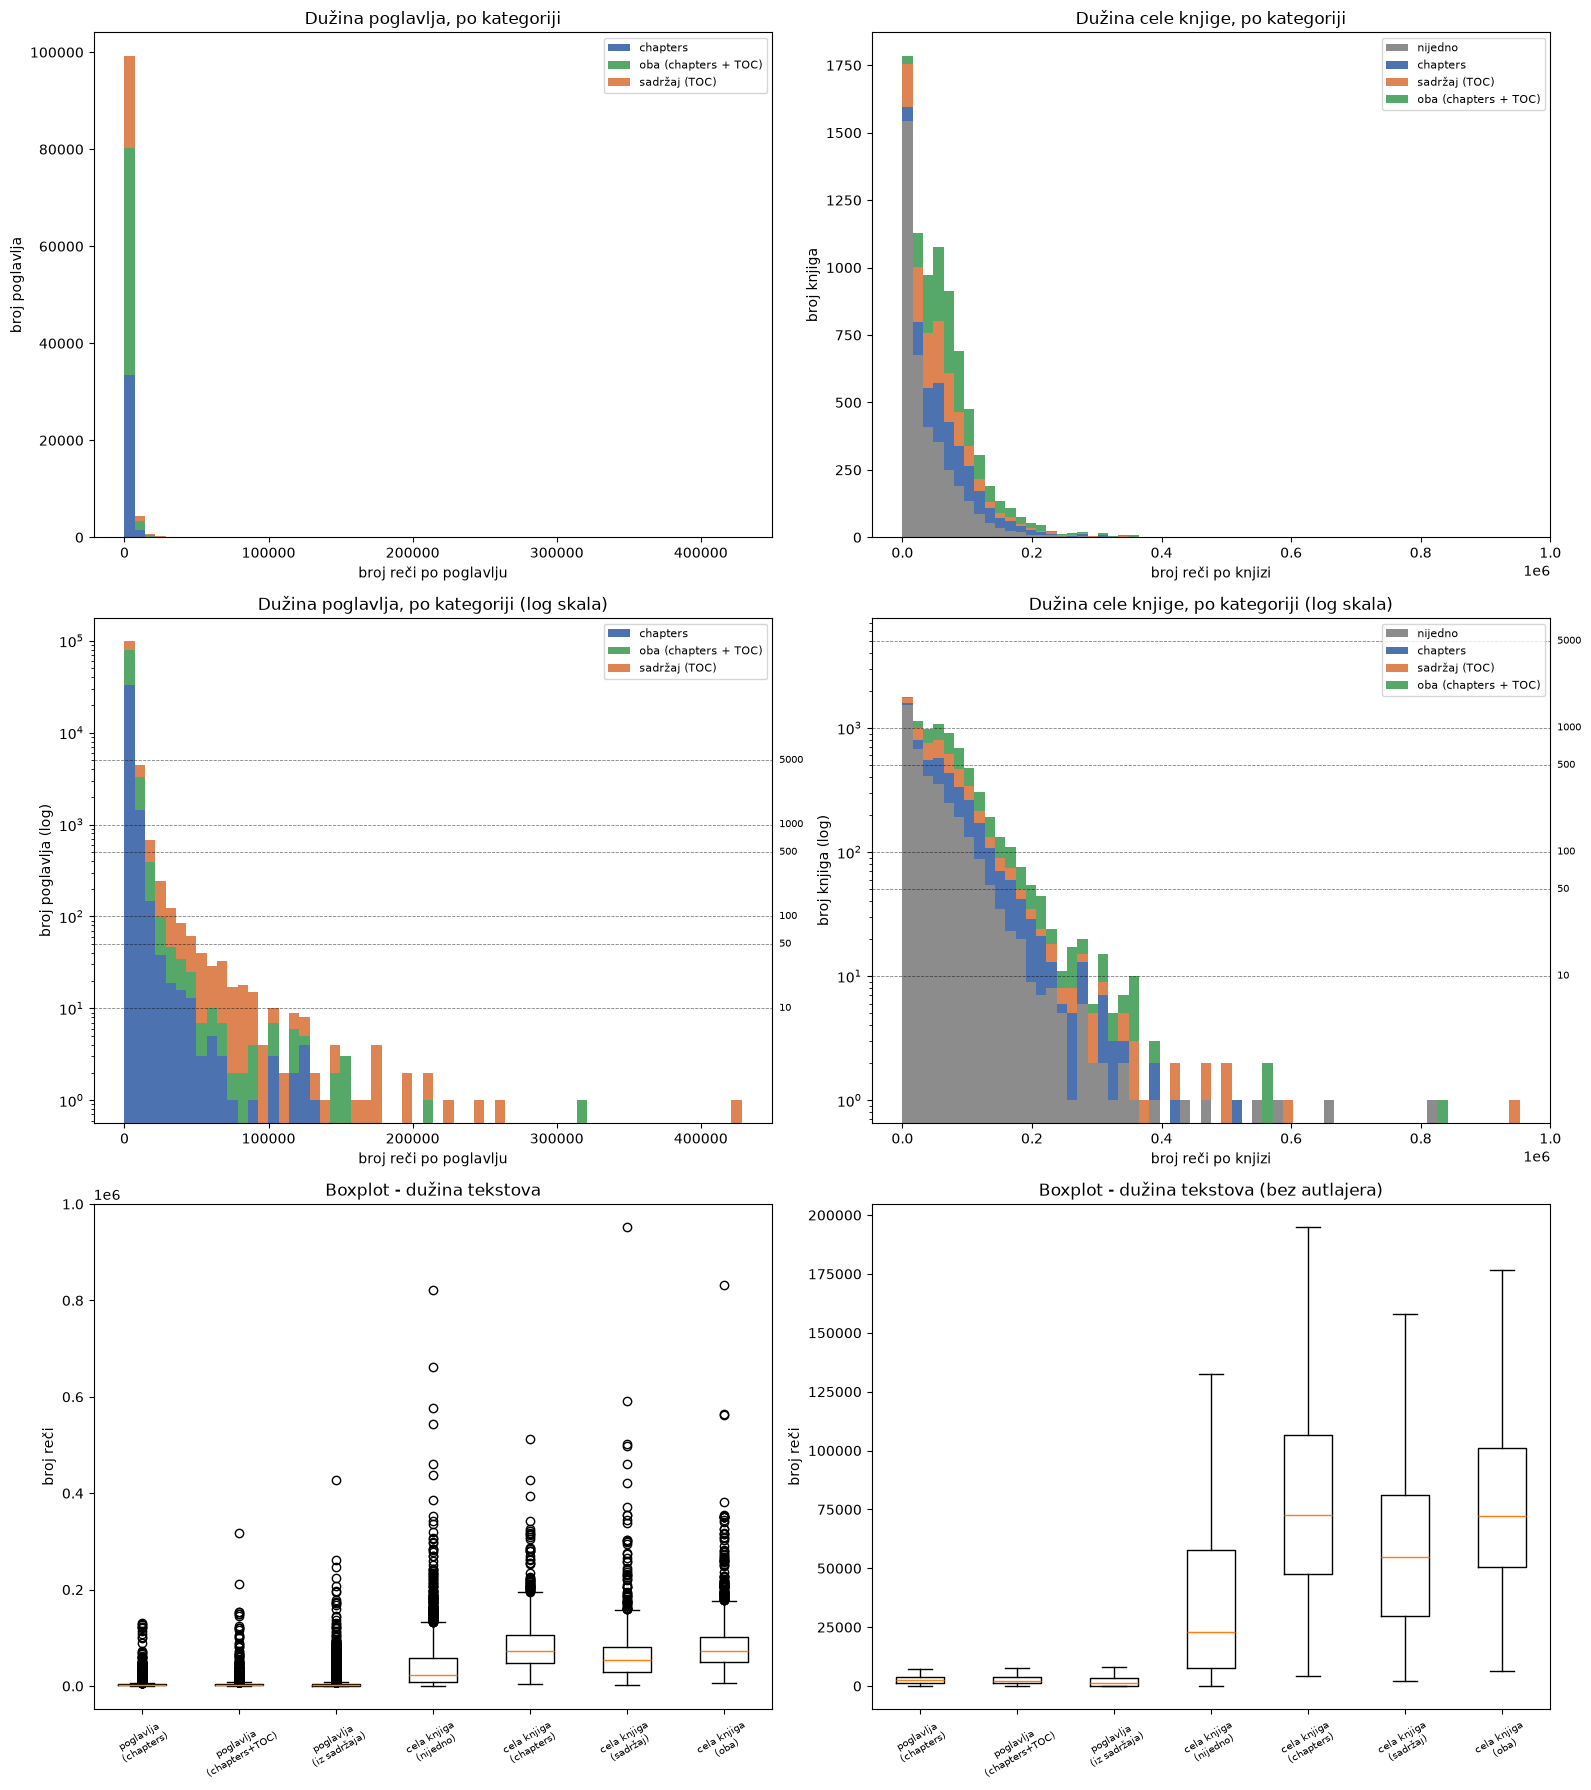

Histogram/boxplot sačuvan na putanji: ..\data\stats\probe_length_distributions.png


In [50]:
plot_length_distributions(df, output_dir)

## Analiza knjiga, žanrova i autora u skupu podataka

Skripta koja se koristi za analizu fajlova u kojima su sačuvane informacije u vezi knjiga, žanrova i autora.

**Cilj**: Eksplorativna analiza podataka i upoznavanje sa metapodacima za knjige, žanrove i autore.

**Pitanja na koje analiza odgovara**:
1. Zastupljenost žanrova, koliko ima knjiga u svakom žanru, gleda se genres_expanded.

1. Koje sve uloge pisaca postoje i koliko ima predstavnika za svaku grupu? Koliko ima pisaca koji imaju 2 različite uloge u različitim knjigama?

1. Koliko ima null vrednosti za pisce po poljima? Koliko ima uloga pisaca sa piscima koji imaju bar jednu null vrednost, a koliko njih po ulogama ima sve vrednosti?

1. Prikaz pisaca koji se najčešće pojavljuju u knjigama, odvojeni prikaz po različitim ulogama pisaca (grafik po ulozi).

1. Koliko knjiga ima prazan ili nepostojeći opis? Kakva je distribucija dužine opisa?

1. Da li postoje "placeholder" opisi koji se ponavljaju identično ili skoro identično kod mnogo knjiga (npr. generički tekstovi tipa "No description available", ili opisi izdavača koji se kopiraju kroz više izdanja iste knjige)? 

1. Da li postoji about kod autora - koliko je popunjeno i kakva je distribucija dužine?

1. Procenat knjiga koje imaju/nemaju ISBN13. num_pages, publication_year/month/day — koliko nedostaje, koliko ima nemogućih vrednosti (0 strana, godina u budućnosti, dan 31 za februar i sl.). Odnos ratings_count, average_rating, text_reviews_count — postoji li velika neravnoteža (par knjiga sa desetinama hiljada ocena, ogromna većina sa par ili nula) — bitno za svest o "long tail" problemu kod preporuka, čak i bez treniranja modela.

1. Deskriptivna statistika/distribucije, čisto zbog upoznavanja:
    - Broj autora po knjizi (koautorstvo) — koliko knjiga ima 1, 2, 3+ autora.
    - Top jezici po broju knjiga.
    - Prosečan broj žanrova po knjizi, najčešće kombinacije žanrova koje se pojavljuju zajedno.
    - Produktivnost autora — broj knjiga po autoru (koliko autora ima samo 1 knjigu, koliko ima 10+).
    - Vremenski raspon (publication_year) - u kom periodu je najviše knjiga objavljeno, ima li praznina.

**Rezultat**: Kreiranje grafika i tekstualnog odgovora na ranija pitanja koja su to samo za generalno upoznavanje sa skupom podataka.


# NAREDNE ANALIZE SU SAMO AI GENERISANE NA BRZINU I ZAHTEVAJU DALJA POBOLJŠANJA I RADOVE!

In [24]:
# Podešavanja, konstante i putanje do foldera
BOOKS_PATH = "../data/books_elasticsearch_relational_db.jsonl"
AUTHORS_PATH = "../data/authors.jsonl"
GENRES_PATH = "../data/genres_expanded.jsonl"
OUTPUT_DIR = "../data/stats/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TOP_N_AUTHORS = 20
TOP_N_GENRE_COMBINATIONS = 20
DESCRIPTION_MIN_WORDS = 5
NEAR_DUPLICATE_SAMPLE_CHARS = 100

# Pomoćne funkcije
def print_header(question_number, title):
    print("\n" + "-" * 150)
    print(f"Q{question_number}: {title}")
    print("-" * 150)

def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"  [UPOZORENJE] Neispravan JSON u {path}, linija {line_number}: {e}")
    return records

def save_and_show(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"    Grafik sačuvan na putanji: {path}")
    plt.show()
    plt.close(fig)

def is_missing(value):
    if value is None:
        return True
    if isinstance(value, float) and np.isnan(value):
        return True
    if isinstance(value, str) and value.strip() == "":
        return True
    return False

def to_float_or_nan(value):
    if is_missing(value): 
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def to_int_or_nan(value):
    f = to_float_or_nan(value)
    if np.isnan(f):
        return np.nan
    return int(f)

In [25]:
# 0 - Učitavanje podataka
print_header(0, "Učitavanje podataka")

books_raw = load_jsonl(BOOKS_PATH)
authors_raw = load_jsonl(AUTHORS_PATH)
genres_raw = load_jsonl(GENRES_PATH)

print(f"  Učitano knjiga:   {len(books_raw)}")
print(f"  Učitano autora:   {len(authors_raw)}")
print(f"  Učitano žanrova:  {len(genres_raw)}")

books_df = pd.DataFrame(books_raw)
authors_df = pd.DataFrame(authors_raw)

# Fajl žanrova ima oblik [{"0": "biography"}, ...] - izvlačimo listu naziva žanrova.
genre_names = []
for genre in genres_raw:
    for v in genre.values():
        genre_names.append(v)
        break
genres_df = pd.DataFrame({"genre": genre_names})

display(books_df.head())
display(authors_df.head())
display(genres_df.head())


------------------------------------------------------------------------------------------------------------------------------------------------------
Q0: Učitavanje podataka
------------------------------------------------------------------------------------------------------------------------------------------------------
  Učitano knjiga:   8174
  Učitano autora:   6453
  Učitano žanrova:  16


,book_id,isbn13,title,authors_enriched,description,country_code,language_code,image_url,image_base64,publisher,...,has_image,etext_number,epub3,epub_older,epub_no_images,genres,genres_expanded,liked_percent,review_count,positive_review_count
0,11391295,,The United States Constitution,"[{'author_id': '1048676', 'role': 'Main Author...",This edition shows the 1787 United States Cons...,US,eng,https://images.gr-assets.com/books/1424172601m...,/9j/4AAQSkZJRgABAQEASABIAAD/2wBDAAUDBAQEAwUEBA...,"Amazon Digital Services, Inc.",...,True,5,https://www.gutenberg.org/ebooks/5.epub3.images,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,"[history, historical fiction, biography, non-f...","[biography, historical fiction, history, non-f...",85.714286,7,6
1,14741847,,The Mayflower Compact,"[{'author_id': '1125631', 'role': 'Main Author...",Traces the history and philosophy of the Mayfl...,US,eng,https://s.gr-assets.com/assets/nophoto/book/11...,iVBORw0KGgoAAAANSUhEUgAAAG8AAACUCAMAAACqToeIAA...,Grosset & Dunlap,...,True,7,https://www.gutenberg.org/ebooks/7.epub3.images,https://www.gutenberg.org/ebooks/7.epub.images,https://www.gutenberg.org/ebooks/7.epub.noimages,"[history, historical fiction, biography]","[biography, historical fiction, history]",100.000000,1,1
2,18996330,,Abraham Lincoln's Second Inaugural Address,"[{'author_id': '229', 'role': 'Main Author', '...",,US,eng,https://s.gr-assets.com/assets/nophoto/book/11...,iVBORw0KGgoAAAANSUhEUgAAAG8AAACUCAMAAACqToeIAA...,,...,True,8,https://www.gutenberg.org/ebooks/8.epub3.images,https://www.gutenberg.org/ebooks/8.epub.images,https://www.gutenberg.org/ebooks/8.epub.noimages,"[history, historical fiction, biography, non-f...","[biography, historical fiction, history, non-f...",100.000000,1,1
3,6324090,,Alice's Adventures in Wonderland,"[{'author_id': '8164', 'role': 'Main Author', ...","Source of legend and lyric, reference and conj...",US,eng,https://images.gr-assets.com/books/1391204048m...,/9j/4AAQSkZJRgABAQEASABIAAD/2wBDAAUDBAQEAwUEBA...,Public Domain Books,...,True,11,https://www.gutenberg.org/ebooks/11.epub3.images,https://www.gutenberg.org/ebooks/11.epub.images,https://www.gutenberg.org/ebooks/11.epub.noimages,"[fantasy, paranormal, fiction, children, young...","[children, fantasy, fiction, paranormal, poetr...",80.794702,151,122
4,23324021,9781467757553,Through the Looking-Glass,"[{'author_id': '8164', 'role': 'Main Author', ...","In 1865, English author CHARLES LUTWIDGE DODGS...",US,,https://s.gr-assets.com/assets/nophoto/book/11...,iVBORw0KGgoAAAANSUhEUgAAAG8AAACUCAMAAACqToeIAA...,First Avenue Editions,...,True,12,https://www.gutenberg.org/ebooks/12.epub3.images,https://www.gutenberg.org/ebooks/12.epub.images,https://www.gutenberg.org/ebooks/12.epub.noimages,"[fantasy, paranormal, fiction, children, young...","[biography, children, fantasy, fiction, histor...",100.000000,5,5


,author_id,name,image_url,about,born,died
0,100030,David Ignatius,https://images.gr-assets.com/authors/122322677...,"David Ignatius, a prize-winning columnist for ...",1950-05-26,NaN
1,1000450,Eshkol Nevo,https://images.gr-assets.com/authors/140013669...,Eshkol Nevo was born in Jerusalem in 1971. He ...,NaN,NaN
2,1001076,Washington Matthews,NaN,NaN,NaN,NaN
3,10015,Kate Atkinson,https://images.gr-assets.com/authors/136380183...,Kate Atkinson was born in York and now lives i...,1951-12-20,NaN
4,100161,William Archer,NaN,NaN,NaN,NaN


,genre
0,biography
1,historical fiction
2,thriller
3,poetry
4,history



------------------------------------------------------------------------------------------------------------------------------------------------------
Q1: Zastupljenost žanrova (genres_expanded)
------------------------------------------------------------------------------------------------------------------------------------------------------
    Grafik sačuvan na putanji: ../data/stats/q1_zastupljenost_zanrova.png


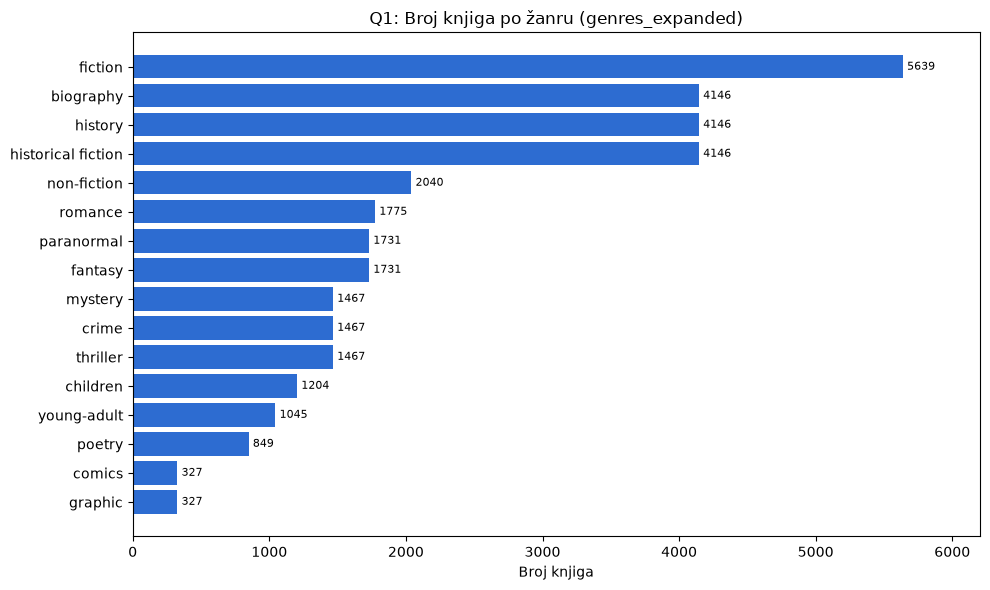

In [26]:
# 1 - Zastupljenost žanrova
print_header(1, "Zastupljenost žanrova (genres_expanded)")

genre_counter = Counter()
for genre_list in books_df["genres_expanded"]:
    genre_counter.update(genre_list)

genre_counts_df = (
    pd.DataFrame(genre_counter.items(), columns=["genre", "book_count"])
    .sort_values("book_count", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(genre_counts_df["genre"], genre_counts_df["book_count"], color="#2D6CD1")
ax.invert_yaxis()
ax.set_xlabel("Broj knjiga")
ax.set_title("Q1: Broj knjiga po žanru (genres_expanded)")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlim(0, genre_counts_df["book_count"].max() * 1.1)

save_and_show(fig, "q1_zastupljenost_zanrova.png")

In [27]:
# 2 - Uloge autora
print_header(2, "Uloge autora i broj predstavnika po ulozi i pisci sa više uloga")

author_roles = {}  # author_id -> set(roles)
author_names_by_id = {}  # author_id -> name

for authors_list in books_df.get("authors_enriched", pd.Series(dtype=object)):
    for a in authors_list:
        author_id = a.get("author_id")
        role = a.get("role")
        name = a.get("name")
        if author_id is None:
            continue
        author_roles.setdefault(author_id, set())
        if not is_missing(role):
            author_roles[author_id].add(role)
        if name:
            author_names_by_id[author_id] = name

# Broj jedinstvenih autora po ulozi
role_to_authors = {}
for author_id, roles in author_roles.items():
    for role in roles:
        role_to_authors.setdefault(role, set()).add(author_id)

role_counts_df = (
    pd.DataFrame(
        [(role, len(ids)) for role, ids in role_to_authors.items()],
        columns=["role", "distinct_author_count"],
    )
    .sort_values("distinct_author_count", ascending=False)
    .reset_index(drop=True)
)

print(f"Sve postojeće uloge i broj različitih autora po ulozi, ukupno postoji {len(role_counts_df)} različitih uloga:")
print(role_counts_df.to_string(index=False))

# Autori sa 2+ različite uloge (kroz različite knjige)
multi_role_authors = {aid: roles for aid, roles in author_roles.items() if len(roles) >= 2}
print(f"\n  Broj autora sa 2 ili više različitih uloga: {len(multi_role_authors)}")
if multi_role_authors:
    preview = [
        {"author_id": aid, "name": author_names_by_id.get(aid, ""), "roles": sorted(roles)}
        for aid, roles in list(multi_role_authors.items())[:10]
    ]
    print("  Primeri autora sa više uloga:")
    for row in preview:
        print(f"    - {row['name']} (id: {row['author_id']}): {row['roles']}")

print("Ideja jeste da se prikažu sve ove uloge autora u knjigama i da se prilikom izbora šta je autor za knjigu prikaže padajuća lista koja se može pretražiti ili dodati nova uloga.")


------------------------------------------------------------------------------------------------------------------------------------------------------
Q2: Uloge autora i broj predstavnika po ulozi i pisci sa više uloga
------------------------------------------------------------------------------------------------------------------------------------------------------
Sve postojeće uloge i broj različitih autora po ulozi, ukupno postoji 139 različitih uloga:
                            role  distinct_author_count
                     Main Author                   4892
                      Translator                    391
                     Illustrator                    307
                          Editor                    305
                    Introduction                    224
                     Contributor                    102
                     Translation                     34
                      translator                     33
                        Narrator 

In [28]:
# 3 - Null vrednosti kod autora
print_header(3, "Null vrednosti kod autora (fajl autora) po poljima")

author_fields = ["author_id", "name", "image_url", "about", "born", "died"]
missing_counts = {}
for field in author_fields:
    series = authors_df[field] if field in authors_df.columns else pd.Series([None] * len(authors_df))
    missing_counts[field] = series.apply(is_missing).sum()

missing_df = pd.DataFrame(
    {
        "field": list(missing_counts.keys()),
        "missing_count": list(missing_counts.values()),
        "missing_pct": [round(100 * c / len(authors_df), 2) for c in missing_counts.values()],
    }
)
print(f"Ukupno autora u fajlu autora: {len(authors_df)}")
print(missing_df.to_string(index=False))

# NAPOMENA: "died" je logički null za sve žive autore, pa se posebno izdvaja
# u analizi ispod, da ne bi lažno "kvario" sliku o kompletnosti.

print(
    "\n  [NAPOMENA] Polje 'died' je None za sve žive autore po definiciji, "
    "pa se u analizi kompletnosti ispod posmatra odvojeno od ostalih polja."
)

fields_excluding_died = [f for f in author_fields if f != "died"]

def author_has_any_missing(row, fields):
    return any(is_missing(row.get(f)) for f in fields)

authors_df["_has_missing_excl_died"] = authors_df.apply(
    lambda r: author_has_any_missing(r, fields_excluding_died), axis=1
)
authors_df["_has_missing_incl_died"] = authors_df.apply(
    lambda r: author_has_any_missing(r, author_fields), axis=1
)

# Sada gledamo, po ulozi (iz Q2 mapiranja author_id -> roles), koliko autora u toj
# ulozi ima bar jedno nedostajuće polje, a koliko ih ima kompletne podatke.
author_id_to_missing_excl_died = dict(zip(authors_df["author_id"], authors_df["_has_missing_excl_died"]))

role_completeness_rows = []
for role, author_ids in role_to_authors.items():
    total = len(author_ids)
    with_missing = sum(
        1 for aid in author_ids if author_id_to_missing_excl_died.get(aid, True)  # nepoznat autor tretiramo kao "nedostaje"
    )
    complete = total - with_missing
    role_completeness_rows.append(
        {"role": role, "total_authors": total, "with_at_least_one_missing": with_missing, "fully_complete": complete}
    )

role_completeness_df = pd.DataFrame(role_completeness_rows).sort_values("total_authors", ascending=False)
print("\nPo ulogama - broj autora sa bar jednim nedostajućim poljem vs. potpuno popunjeni (bez 'died'):")
print(role_completeness_df.to_string(index=False))


------------------------------------------------------------------------------------------------------------------------------------------------------
Q3: Null vrednosti kod autora (fajl autora) po poljima
------------------------------------------------------------------------------------------------------------------------------------------------------
Ukupno autora u fajlu autora: 6453
    field  missing_count  missing_pct
author_id              0         0.00
     name              0         0.00
image_url           3172        49.16
    about           3667        56.83
     born           4511        69.91
     died           4922        76.27

  [NAPOMENA] Polje 'died' je None za sve žive autore po definiciji, pa se u analizi kompletnosti ispod posmatra odvojeno od ostalih polja.

Po ulogama - broj autora sa bar jednim nedostajućim poljem vs. potpuno popunjeni (bez 'died'):
                            role  total_authors  with_at_least_one_missing  fully_complete
              


------------------------------------------------------------------------------------------------------------------------------------------------------
Q4: Najčešći autori po knjigama, odvojeno po ulozi
------------------------------------------------------------------------------------------------------------------------------------------------------
  Uloge za koje se pravi zaseban prikaz: ['Adaptation', 'Adapte par', 'Adapted by', 'Adapter', 'Adaptor', 'Afterword', 'Afterword by', 'Alias', 'Annotations', 'Artist', 'Attributed to', 'Author', 'Author & Illustrator', 'Authot', 'Bian Yi', 'Co-Author', 'Co-author', 'Collaboration', 'Collected by', 'Color Art', 'Colourist', 'Commentaires', 'Commentary', 'Commentator', 'Compilation', 'Compiler', 'Conception', 'Contribution by', 'Contributor', 'Cover Artist', 'Cover illustration', 'Creator', 'Curatore', 'Direction', 'Editor', 'Editor & Contributor', 'Editor and Introduction', 'Editor, Contributor', 'Editor, Introduction', 'Editor, Introduct

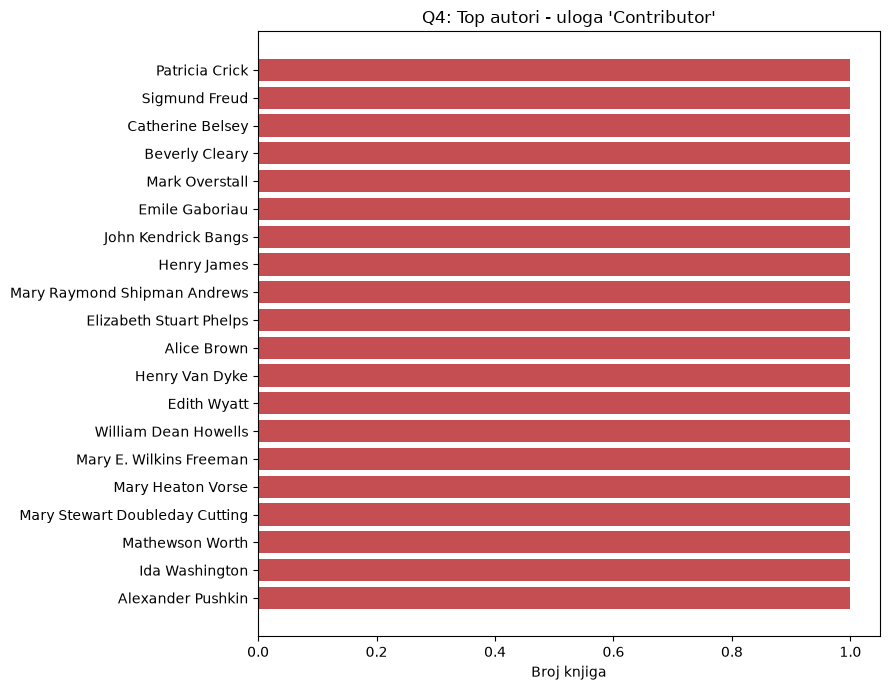


  --- Top 20 autora za ulogu 'Editor' ---
            author_name  book_count
            Andrew Lang          15
       Barbara A. Mowat          11
          Paul Werstine          11
            Harry Bates           4
        John Sutherland           3
      Mabel Loomis Todd           2
       Jennifer Quinlan           2
           David Coward           2
    Melisa Klimaszewski           2
          William Baker           2
            Helen Small           2
  George McKinnon Wrong           2
  Hamilton Wright Mabie           2
          Joseph Jacobs           2
           N. John Hall           2
           H.H. Langton           2
Robert          Jackson           2
        Dan H. Laurence           2
         Kenneth Womack           2
              Roma Gill           2
    Grafik sačuvan na putanji: ../data/stats/q4_top_autori_editor.png


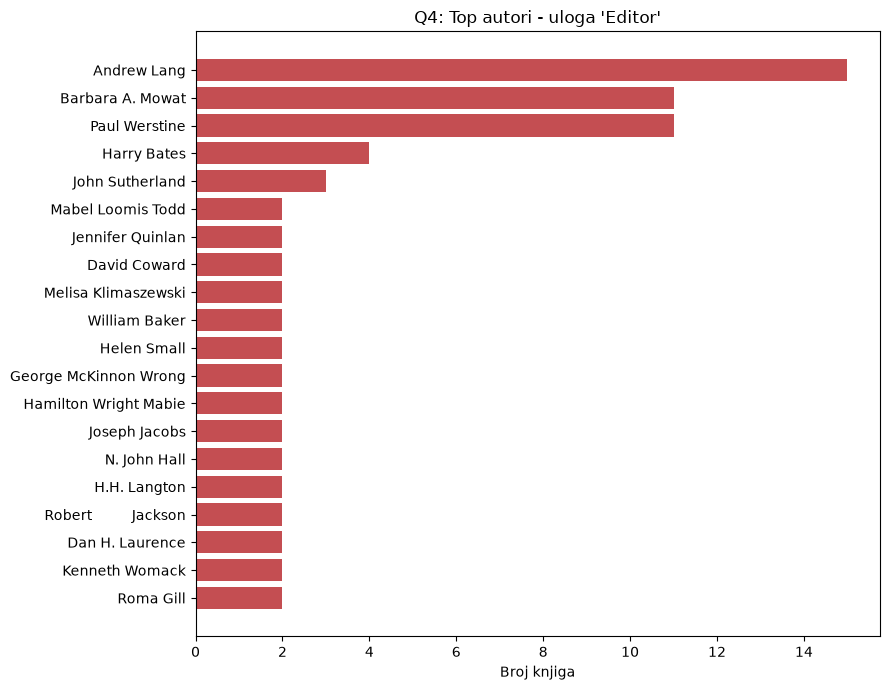


  --- Top 20 autora za ulogu 'Illustrator' ---
            author_name  book_count
     Henry Justice Ford           5
            H.R. Millar           4
         Arthur Rackham           4
         Balliol Salmon           4
          Harrison Cady           3
         Kate Greenaway           3
         John D. Batten           3
             Henry Hutt           3
        John Schoenherr           3
     Robert Emmett Owen           3
           John Tenniel           3
          John R. Neill           3
     May Wilson Preston           2
          Gordon Browne           2
        Harrison Fisher           2
          Frank C. Pape           2
            Thea Kliros           2
  Louis Agassiz Fuertes           2
          Bob Blaisdell           2
Reginald Bathurst Birch           2
    Grafik sačuvan na putanji: ../data/stats/q4_top_autori_illustrator.png


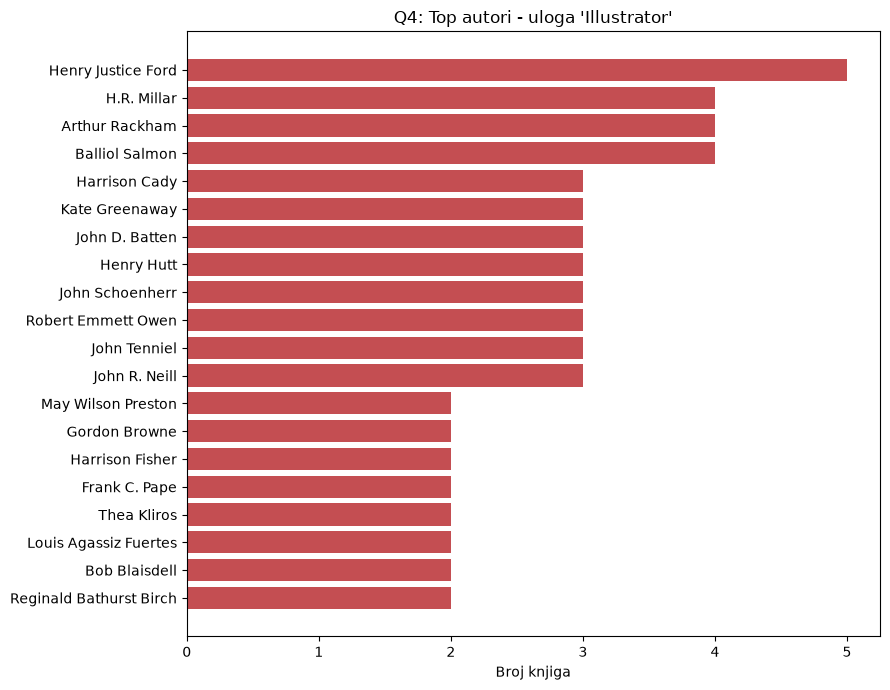


  --- Top 20 autora za ulogu 'Introduction' ---
            author_name  book_count
             Lin Carter           3
             A.S. Byatt           3
        Jack Williamson           3
      Alexander Theroux           2
           Philip Horne           2
             John Clute           2
        Jonathan Lethem           2
         Regina Barreca           2
        William H. Gass           2
       Barbara Cartland           2
       Donald B. Gibson           2
     James H. Pickering           2
John Gregory Betancourt           2
       Vladimir Nabokov           1
     Elizabeth Hardwick           1
       Arthur C. Clarke           1
            Lewis Leary           1
      Kermit Vanderbilt           1
    Carolyn G. Heilbrun           1
           Eva Ibbotson           1
    Grafik sačuvan na putanji: ../data/stats/q4_top_autori_introduction.png


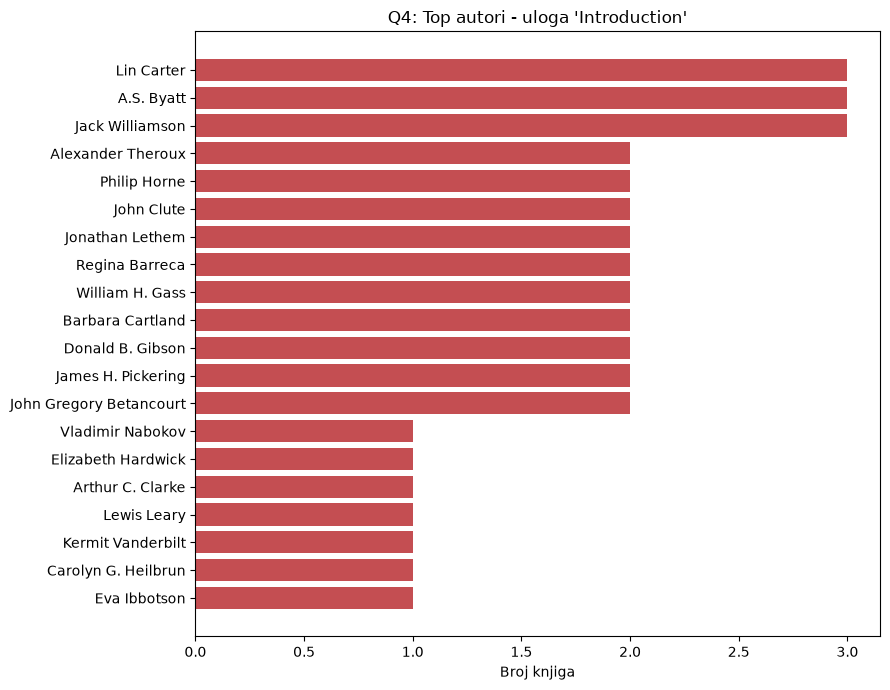


  --- Top 20 autora za ulogu 'Main Author' ---
           author_name  book_count
   William Shakespeare          77
      Honore de Balzac          64
       Charles Dickens          51
      Anthony Trollope          49
            Mark Twain          42
           Henry James          42
             Anonymous          40
           Jules Verne          40
        P.G. Wodehouse          36
      H. Rider Haggard          34
    Arthur Conan Doyle          34
           Jack London          33
                 Plato          33
            H.G. Wells          32
       G.K. Chesterton          32
         L. Frank Baum          29
   Thornton W. Burgess          28
        Wilkie Collins          27
   George Bernard Shaw          27
Robert Louis Stevenson          26
    Grafik sačuvan na putanji: ../data/stats/q4_top_autori_main_author.png


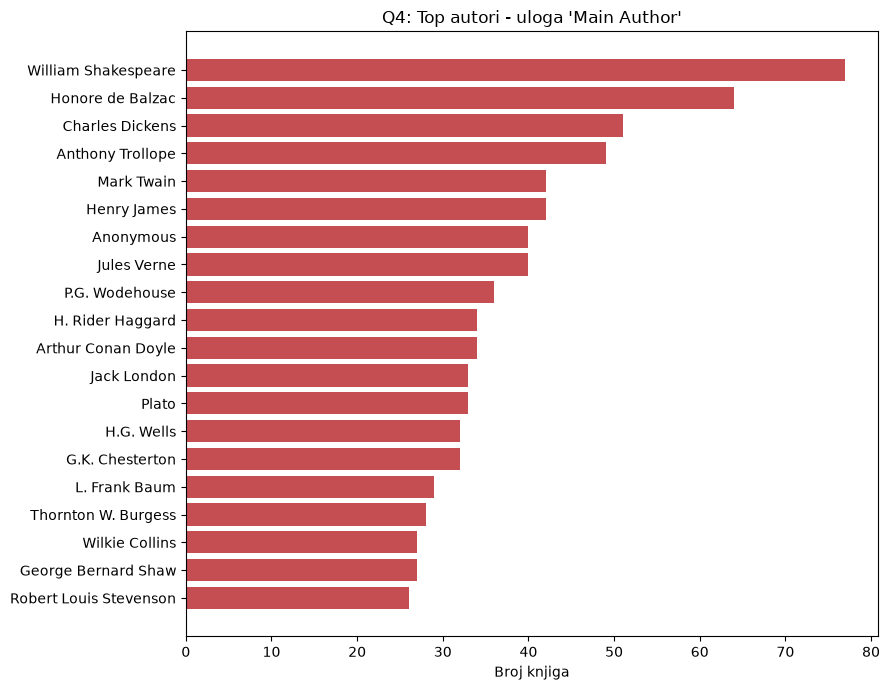


  --- Top 20 autora za ulogu 'Translator' ---
                author_name  book_count
Katherine Prescott Wormeley           5
          Constance Garnett           5
              Tasos Roussos           3
                 Robin Buss           3
             Michael Glenny           3
             Ellen Marriage           3
              Paul Woodruff           2
   Christoph Martin Wieland           2
               Aylmer Maude           2
      Charles E. Derbyshire           2
             George B. Ives           2
      Robin A.H. Waterfield           2
             Alan R. Clarke           2
             Sylvia Raphael           2
            Benjamin Jowett           2
            Peter Kalkavage           2
              Bertan Onaran           2
              Robert Fagles           2
               Ronald Wilks           2
          Alexander Nehamas           2
    Grafik sačuvan na putanji: ../data/stats/q4_top_autori_translator.png


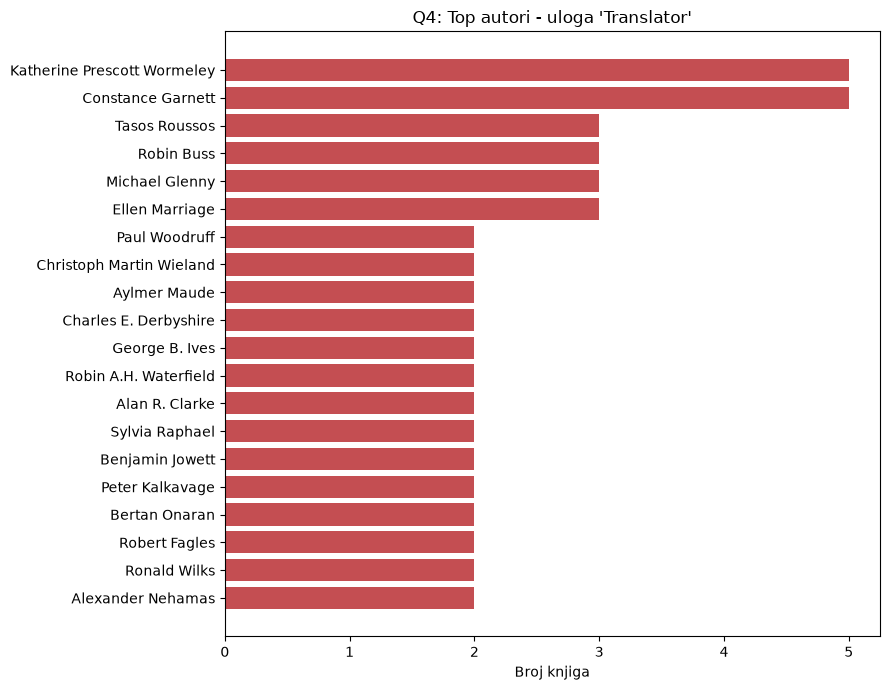

In [29]:
# 4 - Autori koji se najčešće pojavljuju, odvojeno po ulozi
print_header(4, "Najčešći autori po knjigama, odvojeno po ulozi")

# Brojimo pojavljivanja (author_id, role) kroz sve knjige - jedna knjiga = jedno pojavljivanje
role_author_book_counter = Counter()
for authors_list in books_df.get("authors_enriched", pd.Series(dtype=object)):
    if not isinstance(authors_list, list):
        continue
    for a in authors_list:
        author_id = a.get("author_id")
        role = a.get("role")
        if author_id is None or is_missing(role):
            continue
        role_author_book_counter[(role, author_id)] += 1

role_author_df = pd.DataFrame(
    [(role, aid, author_names_by_id.get(aid, aid), cnt) for (role, aid), cnt in role_author_book_counter.items()],
    columns=["role", "author_id", "author_name", "book_count"],
)

all_roles_present = sorted(role_author_df["role"].unique())
print(f"  Uloge za koje se pravi zaseban prikaz: {all_roles_present}")

for role in all_roles_present:
    subset = (
        role_author_df[role_author_df["role"] == role]
        .sort_values("book_count", ascending=False)
    )

    if len(subset) < 100:
        continue

    subset = subset.head(TOP_N_AUTHORS)

    print(f"\n  --- Top {min(TOP_N_AUTHORS, len(subset))} autora za ulogu '{role}' ---")
    print(subset[["author_name", "book_count"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(subset))))
    ax.barh(subset["author_name"], subset["book_count"], color="#C44E52")
    ax.invert_yaxis()
    ax.set_xlabel("Broj knjiga")
    safe_role = re.sub(r"[^a-zA-Z0-9]+", "_", role.lower()).strip("_")
    ax.set_title(f"Q4: Top autori - uloga '{role}'")
    save_and_show(fig, f"q4_top_autori_{safe_role}.png")


------------------------------------------------------------------------------------------------------------------------------------------------------
Q5: Prazni opisi knjiga i distribucija dužine opisa
------------------------------------------------------------------------------------------------------------------------------------------------------
  Ukupno knjiga: 8174
  Knjiga bez opisa (prazan/nepostojeći description): 1741 (21.3%)

  Statistika dužine opisa u rečima (samo za knjige koje IMAJU opis):
count    6433.000000
mean      117.020986
std        84.926395
min         1.000000
25%        55.000000
50%       102.000000
75%       158.000000
max       678.000000

  Knjiga sa opisom kraćim od 5 reči: 36
    Grafik sačuvan na putanji: ../data/stats/q5_distribucija_duzine_opisa.png


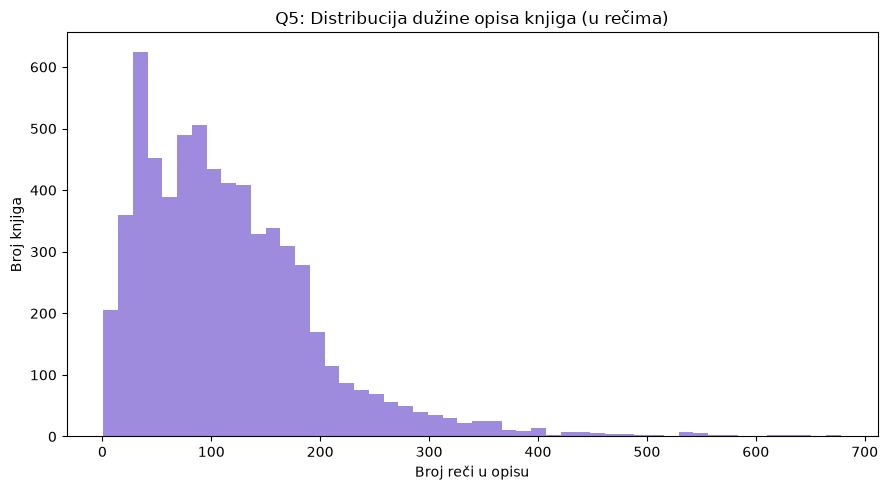

In [30]:
# 5 - Prazni/nepostojeći opisi knjiga i distribucija dužine opisa
print_header(5, "Prazni opisi knjiga i distribucija dužine opisa")

books_df["_description"] = books_df.get("description", pd.Series([None] * len(books_df)))
books_df["_description_is_missing"] = books_df["_description"].apply(is_missing)
n_missing_desc = books_df["_description_is_missing"].sum()
n_total_books = len(books_df)

print(f"  Ukupno knjiga: {n_total_books}")
print(f"  Knjiga bez opisa (prazan/nepostojeći description): {n_missing_desc} "
      f"({round(100 * n_missing_desc / n_total_books, 2)}%)")

books_df["_description_word_count"] = books_df["_description"].apply(
    lambda d: 0 if is_missing(d) else len(str(d).split())
)
books_df["_description_char_count"] = books_df["_description"].apply(
    lambda d: 0 if is_missing(d) else len(str(d))
)

desc_stats = books_df.loc[~books_df["_description_is_missing"], "_description_word_count"].describe()
print("\n  Statistika dužine opisa u rečima (samo za knjige koje IMAJU opis):")
print(desc_stats.to_string())

n_very_short = (
    (~books_df["_description_is_missing"])
    & (books_df["_description_word_count"] < DESCRIPTION_MIN_WORDS)
).sum()
print(f"\n  Knjiga sa opisom kraćim od {DESCRIPTION_MIN_WORDS} reči: {n_very_short}")

fig, ax = plt.subplots(figsize=(9, 5))
non_missing_word_counts = books_df.loc[~books_df["_description_is_missing"], "_description_word_count"]
ax.hist(non_missing_word_counts, bins=50, color="#9E8BDD")
ax.set_xlabel("Broj reči u opisu")
ax.set_ylabel("Broj knjiga")
ax.set_title("Q5: Distribucija dužine opisa knjiga (u rečima)")
save_and_show(fig, "q5_distribucija_duzine_opisa.png")

In [31]:
# 6 - Placeholder opisi koji se ponavljaju kod knjiga

print_header(6, "Placeholder / duplirani opisi knjiga")

non_missing_desc_df = books_df.loc[~books_df["_description_is_missing"], ["book_id", "title", "_description"]].copy()

# 1) Tačni duplikati (identičan tekst opisa kod više knjiga)
exact_desc_counts = non_missing_desc_df["_description"].value_counts()
exact_duplicates = exact_desc_counts[exact_desc_counts > 1]

print(f"  Broj RAZLIČITIH tekstova opisa koji se ponavljaju identično kod 2+ knjige: {len(exact_duplicates)}")
print(f"  Ukupno knjiga pogođeno tačnim duplikatima opisa: {exact_duplicates.sum()}")

if len(exact_duplicates) > 0:
    print("\n  Top 5 najčešće ponovljenih identičnih opisa (prefiks teksta / broj knjiga):")
    for desc_text, count in exact_duplicates.head(5).items():
        prefix = desc_text[:NEAR_DUPLICATE_SAMPLE_CHARS].replace("\n", " ")
        print(f"    [{count}x] \"{prefix}...\"")

# 2) Gruba heuristika za "skoro identične" opise: normalizacija (lowercase, bez interpunkcije/whitespace-a)
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

non_missing_desc_df["_normalized"] = non_missing_desc_df["_description"].apply(normalize_text)
normalized_counts = non_missing_desc_df["_normalized"].value_counts()
near_duplicates = normalized_counts[normalized_counts > 1]

# Oduzimamo one koje su već pokrivene tačnim duplikatima da vidimo da li normalizacija otkriva JOŠ nešto
print(f"\n  Broj grupa 'skoro identičnih' opisa (posle normalizacije interpunkcije/razmaka): {len(near_duplicates)}")
print(f"  Ukupno knjiga pogođeno (uključujući i tačne duplikate): {near_duplicates.sum()}")

# 3) Tipični placeholder izrazi - eksplicitna provera poznatih fraza
placeholder_phrases = [
    "no description available",
    "description forthcoming",
    "synopsis coming soon",
    "publisher's description",
    "n/a",
]
for phrase in placeholder_phrases:
    hits = non_missing_desc_df["_normalized"].str.contains(re.escape(phrase), na=False).sum()
    if hits > 0:
        print(f"  Fraza '{phrase}' pronađena u {hits} opisa")


------------------------------------------------------------------------------------------------------------------------------------------------------
Q6: Placeholder / duplirani opisi knjiga
------------------------------------------------------------------------------------------------------------------------------------------------------
  Broj RAZLIČITIH tekstova opisa koji se ponavljaju identično kod 2+ knjige: 92
  Ukupno knjiga pogođeno tačnim duplikatima opisa: 628

  Top 5 najčešće ponovljenih identičnih opisa (prefiks teksta / broj knjiga):
    [204x] "This book was converted from its physical edition to the digital format by a community of volunteers..."
    [96x] "This is a pre-1923 historical reproduction that was curated for quality. Quality assurance was condu..."
    [45x] "Many of the earliest books, particularly those dating back to the 1900s and before, are now extremel..."
    [30x] "This work has been selected by scholars as being culturally important, and is part


------------------------------------------------------------------------------------------------------------------------------------------------------
Q7: Popunjenost i dužina 'about' polja kod autora
------------------------------------------------------------------------------------------------------------------------------------------------------
  Ukupno autora: 6453
  Autora BEZ 'about' teksta: 3667 (56.83%)
  Autora SA 'about' tekstom: 2786 (43.17%)

  Statistika dužine 'about' u rečima (samo za autore koji ga imaju):
count    2786.000000
mean      170.839555
std       153.042287
min         1.000000
25%        62.000000
50%       118.000000
75%       231.000000
max       705.000000
    Grafik sačuvan na putanji: ../data/stats/q7_distribucija_duzine_about.png


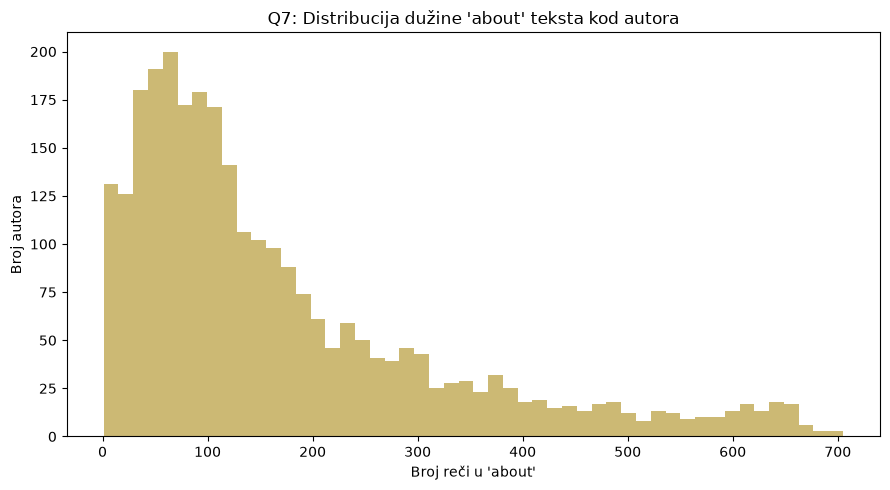

In [32]:
# 7 - Popunjenost i dužina biografije autora

print_header(7, "Popunjenost i dužina 'about' polja kod autora")

authors_df["_about"] = authors_df.get("about", pd.Series([None] * len(authors_df)))
authors_df["_about_is_missing"] = authors_df["_about"].apply(is_missing)

n_authors_total = len(authors_df)
n_about_missing = authors_df["_about_is_missing"].sum()
print(f"  Ukupno autora: {n_authors_total}")
print(f"  Autora BEZ 'about' teksta: {n_about_missing} ({round(100 * n_about_missing / n_authors_total, 2)}%)")
print(f"  Autora SA 'about' tekstom: {n_authors_total - n_about_missing} "
      f"({round(100 * (n_authors_total - n_about_missing) / n_authors_total, 2)}%)")

authors_df["_about_word_count"] = authors_df["_about"].apply(
    lambda a: 0 if is_missing(a) else len(str(a).split())
)

about_stats = authors_df.loc[~authors_df["_about_is_missing"], "_about_word_count"].describe()
print("\n  Statistika dužine 'about' u rečima (samo za autore koji ga imaju):")
print(about_stats.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(authors_df.loc[~authors_df["_about_is_missing"], "_about_word_count"], bins=50, color="#CCB974")
ax.set_xlabel("Broj reči u 'about'")
ax.set_ylabel("Broj autora")
ax.set_title("Q7: Distribucija dužine 'about' teksta kod autora")
save_and_show(fig, "q7_distribucija_duzine_about.png")


------------------------------------------------------------------------------------------------------------------------------------------------------
Q8: ISBN13 / num_pages / datumi objavljivanja / long-tail ocena
------------------------------------------------------------------------------------------------------------------------------------------------------
  Knjiga BEZ isbn13: 2488 (30.44%)
  Knjiga SA isbn13: 5686 (69.56%)

  Knjiga bez num_pages (nedostaje/nije broj): 3130
  Knjiga sa num_pages == 0 (nemoguća vrednost): 10
  Statistika num_pages (za validne, > 0 vrednosti):
count    5034.000000
mean      252.233214
std       170.234856
min         1.000000
25%       128.000000
50%       226.000000
75%       336.000000
max      1463.000000

  Knjiga bez publication_year: 2834
  Knjiga sa publication_year u budućnosti (> 2026): 0
  Knjiga sa nevalidnim publication_month (van 1-12): 0
  Knjiga sa nevalidnim publication_day (van 1-31 ili van broja dana u mesecu): 10

  Statistika

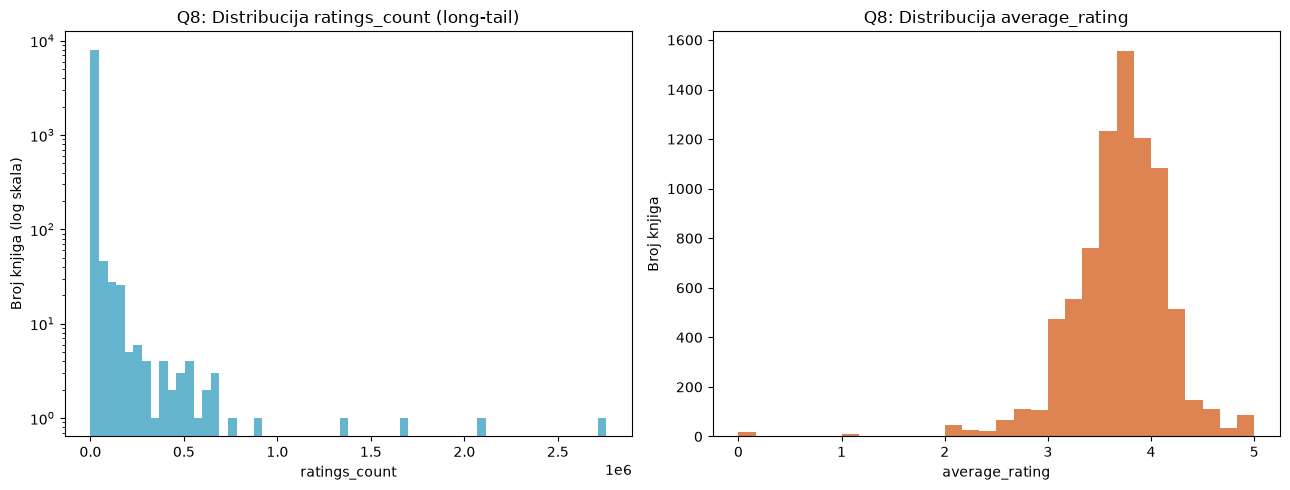

In [33]:
# 8 - Procenat knjige koje imaju/nemaju određena polja

print_header(8, "ISBN13 / num_pages / datumi objavljivanja / long-tail ocena")

# --- ISBN13 ---
books_df["_isbn13_missing"] = books_df.get("isbn13", pd.Series([None] * len(books_df))).apply(is_missing)
n_isbn_missing = books_df["_isbn13_missing"].sum()
print(f"  Knjiga BEZ isbn13: {n_isbn_missing} ({round(100 * n_isbn_missing / n_total_books, 2)}%)")
print(f"  Knjiga SA isbn13: {n_total_books - n_isbn_missing} "
      f"({round(100 * (n_total_books - n_isbn_missing) / n_total_books, 2)}%)")

# --- num_pages ---
books_df["_num_pages"] = books_df.get("num_pages", pd.Series([None] * len(books_df))).apply(to_int_or_nan)
n_pages_missing = books_df["_num_pages"].isna().sum()
n_pages_zero = (books_df["_num_pages"] == 0).sum()
print(f"\n  Knjiga bez num_pages (nedostaje/nije broj): {n_pages_missing}")
print(f"  Knjiga sa num_pages == 0 (nemoguća vrednost): {n_pages_zero}")
print("  Statistika num_pages (za validne, > 0 vrednosti):")
valid_pages = books_df.loc[books_df["_num_pages"] > 0, "_num_pages"]
print(valid_pages.describe().to_string())

# --- Datumi objavljivanja ---
books_df["_pub_year"] = books_df.get("publication_year", pd.Series([None] * len(books_df))).apply(to_int_or_nan)
books_df["_pub_month"] = books_df.get("publication_month", pd.Series([None] * len(books_df))).apply(to_int_or_nan)
books_df["_pub_day"] = books_df.get("publication_day", pd.Series([None] * len(books_df))).apply(to_int_or_nan)

current_year = pd.Timestamp.now().year

n_year_missing = books_df["_pub_year"].isna().sum()
n_year_future = (books_df["_pub_year"] > current_year).sum()
n_month_invalid = (~books_df["_pub_month"].isna() & ((books_df["_pub_month"] < 1) | (books_df["_pub_month"] > 12))).sum()

def is_day_invalid_for_month(row):
    year, month, day = row["_pub_year"], row["_pub_month"], row["_pub_day"]
    if np.isnan(day):
        return False
    if day < 1 or day > 31:
        return True
    if np.isnan(month) or month < 1 or month > 12:
        return False  # mesec je već prijavljen kao nevalidan gore; ne dupliramo
    days_in_month = {
        1: 31, 2: 29, 3: 31, 4: 30, 5: 31, 6: 30,
        7: 31, 8: 30, 9: 31, 10: 31, 11: 30, 12: 31,
    }  # februar konzervativno na 29 (prestupna godina) da ne lažiramo broj grešaka
    return day > days_in_month.get(int(month), 31)

n_day_invalid = books_df.apply(is_day_invalid_for_month, axis=1).sum()

print(f"\n  Knjiga bez publication_year: {n_year_missing}")
print(f"  Knjiga sa publication_year u budućnosti (> {current_year}): {n_year_future}")
print(f"  Knjiga sa nevalidnim publication_month (van 1-12): {n_month_invalid}")
print(f"  Knjiga sa nevalidnim publication_day (van 1-31 ili van broja dana u mesecu): {n_day_invalid}")

# --- ratings_count / average_rating / text_reviews_count (long-tail) ---
books_df["_ratings_count"] = books_df.get("ratings_count", pd.Series([None] * len(books_df))).apply(to_float_or_nan)
books_df["_average_rating"] = books_df.get("average_rating", pd.Series([None] * len(books_df))).apply(to_float_or_nan)
books_df["_text_reviews_count"] = books_df.get("text_reviews_count", pd.Series([None] * len(books_df))).apply(to_float_or_nan)

print("\n  Statistika ratings_count (broj ocena po knjizi):")
print(books_df["_ratings_count"].describe().to_string())

# Long-tail provera: koliki % ukupnih ocena "drži" top 1% / top 5% / top 10% knjiga
ratings_sorted = books_df["_ratings_count"].dropna().sort_values(ascending=False)
total_ratings = ratings_sorted.sum()
for pct in [0.01, 0.05, 0.10]:
    n_top = max(1, int(len(ratings_sorted) * pct))
    share = ratings_sorted.head(n_top).sum() / total_ratings * 100 if total_ratings > 0 else 0
    print(f"  Top {int(pct * 100)}% knjiga po broju ocena drži {round(share, 1)}% svih ocena "
          f"({n_top} od {len(ratings_sorted)} knjiga)")

n_zero_or_missing_ratings = (books_df["_ratings_count"].fillna(0) == 0).sum()
print(f"  Knjiga sa 0 ili nedostajućim ratings_count: {n_zero_or_missing_ratings} "
      f"({round(100 * n_zero_or_missing_ratings / n_total_books, 2)}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(books_df["_ratings_count"].dropna(), bins=60, color="#64B5CD")
axes[0].set_yscale("log")
axes[0].set_xlabel("ratings_count")
axes[0].set_ylabel("Broj knjiga (log skala)")
axes[0].set_title("Q8: Distribucija ratings_count (long-tail)")

axes[1].hist(books_df["_average_rating"].dropna(), bins=30, color="#DD8452")
axes[1].set_xlabel("average_rating")
axes[1].set_ylabel("Broj knjiga")
axes[1].set_title("Q8: Distribucija average_rating")
save_and_show(fig, "q8_ratings_distribucija.png")


------------------------------------------------------------------------------------------------------------------------------------------------------
Q9.1: Broj autora po knjizi (koautorstvo)
------------------------------------------------------------------------------------------------------------------------------------------------------
_num_authors
0        1
1     6407
2     1348
3      306
4       63
5       24
6        8
7        3
8        2
12       4
16       1
17       2
18       1
32       2
41       1
51       1
    Grafik sačuvan na putanji: ../data/stats/q9_1_broj_autora_po_knjizi.png


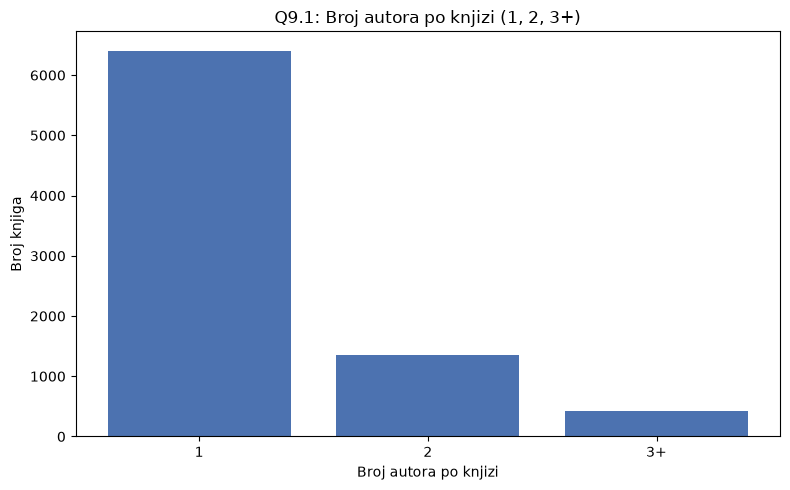


------------------------------------------------------------------------------------------------------------------------------------------------------
Q9.2: Top jezici po broju knjiga
------------------------------------------------------------------------------------------------------------------------------------------------------
language_code
(nepoznato)    4822
eng            2424
en-US           218
en-GB           128
fre             111
ger              98
fin              85
spa              66
ita              54
por              35
nl               35
gre              18
swe              10
ind               9
dan               9
zho               8
grc               5
en-CA             4
est               3
nor               3
msa               3
rum               3
srp               3
tur               3
mul               2
pol               2
jpn               2
lav               2
bul               1
sco               1
cat               1
vie               1
elx       

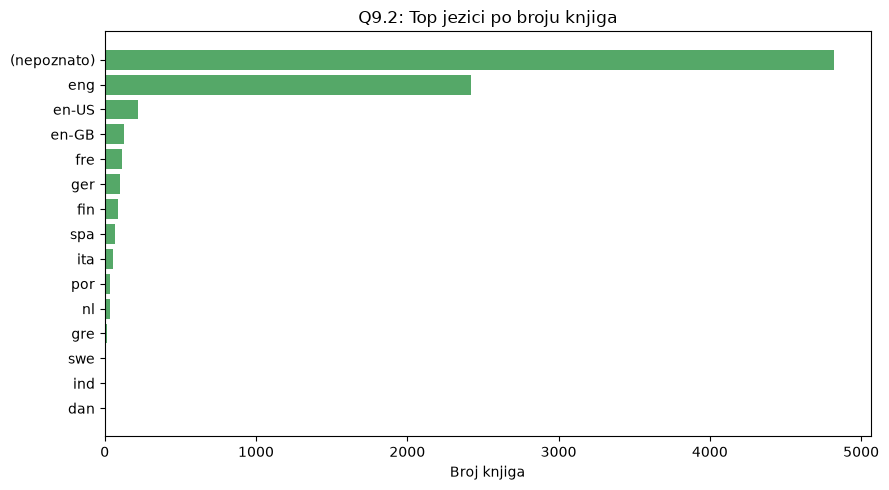


------------------------------------------------------------------------------------------------------------------------------------------------------
Q9.3: Prosečan broj žanrova po knjizi i najčešće kombinacije
------------------------------------------------------------------------------------------------------------------------------------------------------
  Prosečan broj žanrova po knjizi: 4.1
  Medijana broja žanrova po knjizi: 4.0
  Distribucija broja žanrova po knjizi:
_num_genres
0      816
1     1074
2      502
3      724
4     1496
5     1247
6      796
7      645
8      431
9      241
10     118
11      63
12      19
13       1
16       1

  Top 20 najčešćih parova žanrova koji se pojavljuju zajedno:
            zanr_1             zanr_2  broj_knjiga
         biography historical fiction         4146
         biography            history         4146
historical fiction            history         4146
         biography            fiction         3150
           fiction    

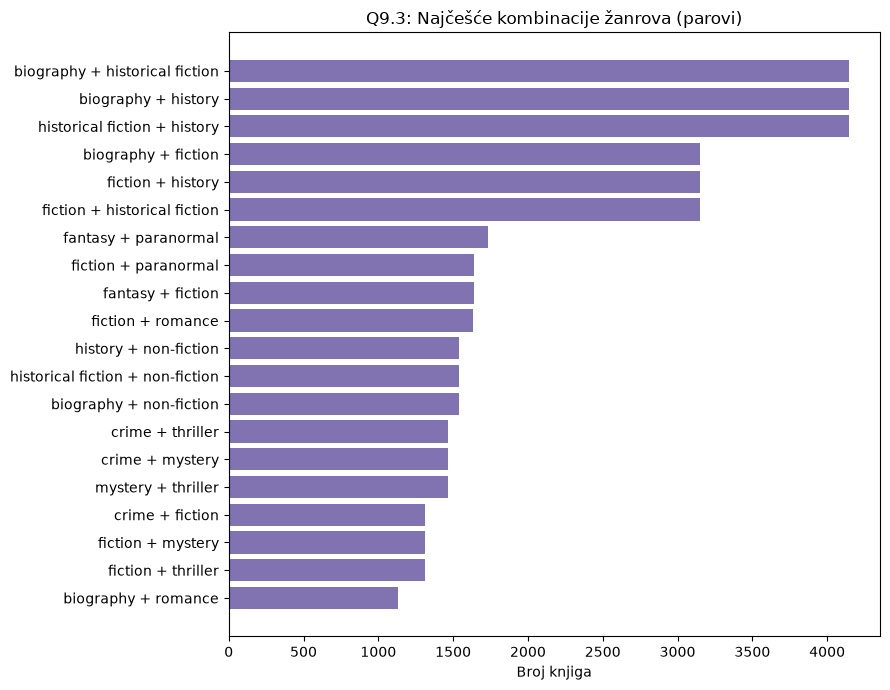


------------------------------------------------------------------------------------------------------------------------------------------------------
Q9.4: Produktivnost autora (broj knjiga po autoru)
------------------------------------------------------------------------------------------------------------------------------------------------------
  Autora sa tačno 1 knjigom: 5300
  Autora sa 2-5 knjiga: 916
  Autora sa 6-10 knjiga: 142
  Autora sa 10+ knjiga: 95

  Statistika broja knjiga po autoru:
count    6453.000000
mean        1.665892
std         2.958057
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        78.000000

  Top 20 najproduktivnijih autora (bez obzira na ulogu):
           author_name  book_count
   William Shakespeare          78
      Honore de Balzac          64
       Charles Dickens          51
      Anthony Trollope          49
            Mark Twain          43
           Henry James          43
           Jules Ve

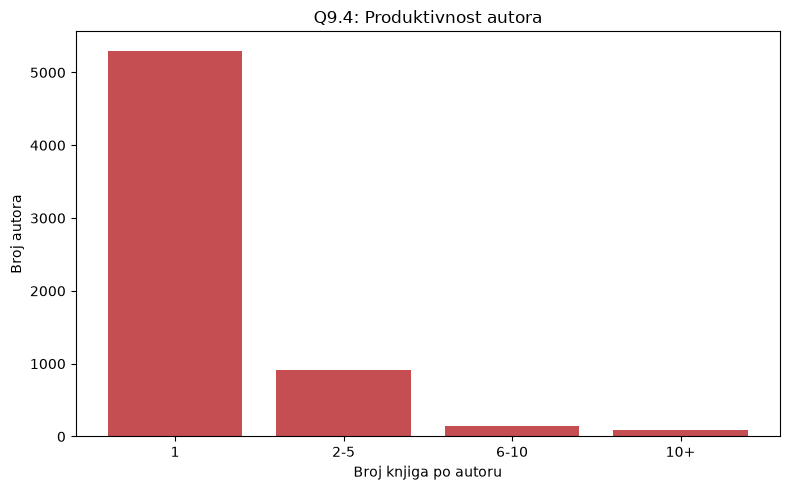


------------------------------------------------------------------------------------------------------------------------------------------------------
Q9.5: Vremenski raspon objavljivanja (publication_year)
------------------------------------------------------------------------------------------------------------------------------------------------------
  Najranija godina objavljivanja: 1623
  Najkasnija godina objavljivanja: 2018
  Broj knjiga bez validne godine: 2834
  Broj godina bez ijedne knjige unutar opsega [1623, 2018]: 245
    Primer godina-praznina (do 20): [1624, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643]
    Grafik sačuvan na putanji: ../data/stats/q9_5_godine_objavljivanja.png


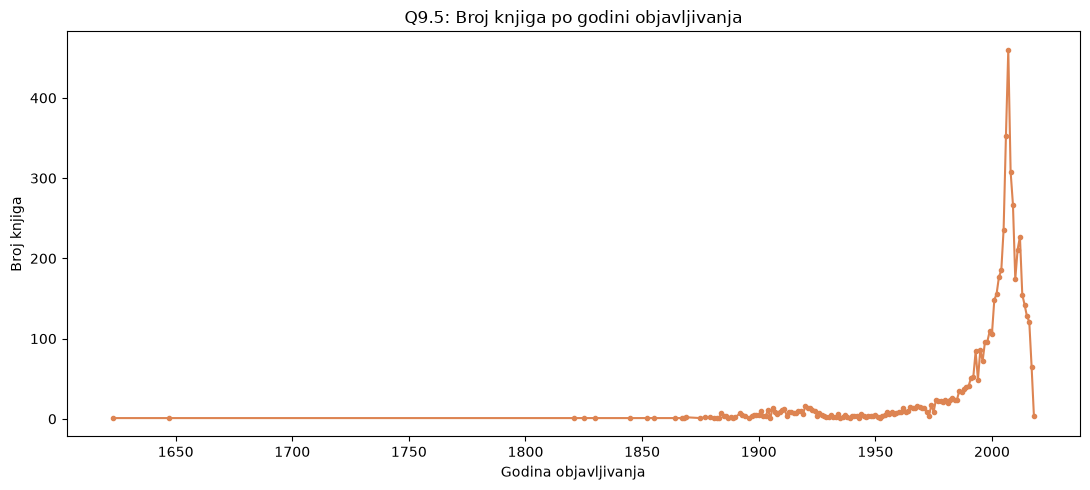


Analiza završena. Svi grafici sačuvani u: d:\Projects\AI-agent-za-biblioteku\VectorDatabaseService\data\stats


In [34]:
# 9 - Deskriptivna statistika

print_header("9.1", "Broj autora po knjizi (koautorstvo)")

books_df["_num_authors"] = books_df.get("authors_enriched", pd.Series([[]] * len(books_df))).apply(
    lambda a: len(a) if isinstance(a, list) else 0
)
authors_per_book_counts = books_df["_num_authors"].value_counts().sort_index()
print(authors_per_book_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
# Grupišemo 3+ zajedno radi preglednosti, kao što je pitanje i formulisano (1, 2, 3+)
capped = books_df["_num_authors"].apply(lambda n: str(n) if n < 3 else "3+")
order = [v for v in ["1", "2", "3+"] if v in capped.unique()]
capped_counts = capped.value_counts().reindex(order)
ax.bar(capped_counts.index.astype(str), capped_counts.values, color="#4C72B0")
ax.set_xlabel("Broj autora po knjizi")
ax.set_ylabel("Broj knjiga")
ax.set_title("Q9.1: Broj autora po knjizi (1, 2, 3+)")
save_and_show(fig, "q9_1_broj_autora_po_knjizi.png")


print_header("9.2", "Top jezici po broju knjiga")

lang_counts = books_df.get("language_code", pd.Series(dtype=object)).replace("", np.nan).fillna("(nepoznato)").value_counts()
print(lang_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
top_langs = lang_counts.head(15)
ax.barh(top_langs.index.astype(str), top_langs.values, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Broj knjiga")
ax.set_title("Q9.2: Top jezici po broju knjiga")
save_and_show(fig, "q9_2_top_jezici.png")


print_header("9.3", "Prosečan broj žanrova po knjizi i najčešće kombinacije")

books_df["_num_genres"] = books_df.get("genres_expanded", pd.Series([[]] * len(books_df))).apply(
    lambda g: len(g) if isinstance(g, list) else 0
)
print(f"  Prosečan broj žanrova po knjizi: {round(books_df['_num_genres'].mean(), 2)}")
print(f"  Medijana broja žanrova po knjizi: {books_df['_num_genres'].median()}")
print("  Distribucija broja žanrova po knjizi:")
print(books_df["_num_genres"].value_counts().sort_index().to_string())

combo_counter = Counter()
for genres_list in books_df.get("genres_expanded", pd.Series(dtype=object)):
    if isinstance(genres_list, list) and len(genres_list) >= 2:
        for pair in combinations(sorted(set(genres_list)), 2):
            combo_counter[pair] += 1

combo_df = (
    pd.DataFrame([(a, b, cnt) for (a, b), cnt in combo_counter.items()], columns=["zanr_1", "zanr_2", "broj_knjiga"])
    .sort_values("broj_knjiga", ascending=False)
    .head(TOP_N_GENRE_COMBINATIONS)
)
print(f"\n  Top {TOP_N_GENRE_COMBINATIONS} najčešćih parova žanrova koji se pojavljuju zajedno:")
print(combo_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(combo_df))))
combo_labels = combo_df["zanr_1"] + " + " + combo_df["zanr_2"]
ax.barh(combo_labels, combo_df["broj_knjiga"], color="#8172B2")
ax.invert_yaxis()
ax.set_xlabel("Broj knjiga")
ax.set_title("Q9.3: Najčešće kombinacije žanrova (parovi)")
save_and_show(fig, "q9_3_kombinacije_zanrova.png")


print_header("9.4", "Produktivnost autora (broj knjiga po autoru)")

author_book_counter = Counter()
for authors_list in books_df.get("authors_enriched", pd.Series(dtype=object)):
    if isinstance(authors_list, list):
        for a in authors_list:
            if a.get("author_id") is not None:
                author_book_counter[a["author_id"]] += 1

books_per_author = pd.Series(author_book_counter.values())
print(f"  Autora sa tačno 1 knjigom: {(books_per_author == 1).sum()}")
print(f"  Autora sa 2-5 knjiga: {((books_per_author >= 2) & (books_per_author <= 5)).sum()}")
print(f"  Autora sa 6-10 knjiga: {((books_per_author >= 6) & (books_per_author <= 10)).sum()}")
print(f"  Autora sa 10+ knjiga: {(books_per_author > 10).sum()}")
print("\n  Statistika broja knjiga po autoru:")
print(books_per_author.describe().to_string())

top_prolific = (
    pd.DataFrame({"author_id": list(author_book_counter.keys()), "book_count": list(author_book_counter.values())})
    .assign(author_name=lambda d: d["author_id"].map(author_names_by_id))
    .sort_values("book_count", ascending=False)
    .head(TOP_N_AUTHORS)
)
print(f"\n  Top {TOP_N_AUTHORS} najproduktivnijih autora (bez obzira na ulogu):")
print(top_prolific[["author_name", "book_count"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
bins = [1, 2, 6, 11, books_per_author.max() + 1]
labels = ["1", "2-5", "6-10", "10+"]
binned = pd.cut(books_per_author, bins=bins, labels=labels, right=False)
binned_counts = binned.value_counts().reindex(labels)
ax.bar(binned_counts.index.astype(str), binned_counts.values, color="#C44E52")
ax.set_xlabel("Broj knjiga po autoru")
ax.set_ylabel("Broj autora")
ax.set_title("Q9.4: Produktivnost autora")
save_and_show(fig, "q9_4_produktivnost_autora.png")


print_header("9.5", "Vremenski raspon objavljivanja (publication_year)")

valid_years = books_df.loc[(books_df["_pub_year"] > 0) & (~books_df["_pub_year"].isna()), "_pub_year"].astype(int)
print(f"  Najranija godina objavljivanja: {valid_years.min()}")
print(f"  Najkasnija godina objavljivanja: {valid_years.max()}")
print(f"  Broj knjiga bez validne godine: {n_total_books - len(valid_years)}")

year_counts = valid_years.value_counts().sort_index()
# Provera praznina - godine bez ijedne knjige unutar opsega min-max
full_range = range(int(valid_years.min()), int(valid_years.max()) + 1)
missing_years = [y for y in full_range if y not in year_counts.index]
print(f"  Broj godina bez ijedne knjige unutar opsega [{valid_years.min()}, {valid_years.max()}]: {len(missing_years)}")
if missing_years:
    print(f"    Primer godina-praznina (do 20): {missing_years[:20]}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(year_counts.index, year_counts.values, marker="o", markersize=3, color="#DD8452")
ax.set_xlabel("Godina objavljivanja")
ax.set_ylabel("Broj knjiga")
ax.set_title("Q9.5: Broj knjiga po godini objavljivanja")
save_and_show(fig, "q9_5_godine_objavljivanja.png")


print("\n" + "=" * 100)
print(f"Analiza završena. Svi grafici sačuvani u: {os.path.abspath(OUTPUT_DIR)}")
print("=" * 100)